In [1]:
import json
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.special import stirling2
import math
from copy import copy
import scipy
import tqdm
import pandas as pd

In [2]:
status_codes = {
    1: 'LOADED',
    2: 'OPTIMAL',
    3: 'INFEASIBLE',
    4: 'INF_OR_UNBD',
    5: 'UNBOUNDED',
    6: 'CUTOFF',
    7: 'ITERATION_LIMIT',
    8: 'NODE_LIMIT',
    9: 'TIME_LIMIT',
    10: 'SOLUTION_LIMIT',
    11: 'INTERRUPTED',
    12: 'NUMERIC',
    13: 'SUBOPTIMAL',
    14: 'INPROGRESS',
    15: 'USER_OBJ_LIMIT'
}

In [3]:
rng = np.random.default_rng(643)

# SDP Minimal Working Example

# Multivariate utils

In [4]:
def compute_order(alpha):
    '''Sum of elements of a power.'''
    order = 0
    for alpha_i in alpha:
        order += alpha_i
    return order

def compute_Nd(S, d):
    '''Number of moments of order <= d (S species)'''
    Nd = math.factorial(S + d) // (math.factorial(d) * math.factorial(S))
    return Nd

def compute_powers(S, d):
    '''Compute the Nd powers of order <= d (S species)'''

    # all powers
    powers = [[0 for s in range(S)]]

    # powers of order d = 0
    powers_prev = [[0 for s in range(S)]]

    # for order d = 1, ..., d
    for order in range(1, d + 1):

        # store powers of order d
        powers_current = []

        # for each power of order d - 1
        for alpha in powers_prev:

            # for each index
            for i in range(S):

                # add 1 to power at index
                alpha_new = copy(alpha)
                alpha_new[i] += 1

                # store (avoid repeats)
                if alpha_new not in powers_current:
                    powers_current.append(alpha_new)

        # update d - 1 powers
        powers += powers_current

        # update overall powers
        powers_prev = powers_current

    return powers

def add_powers(*powers, S):
    '''Add powers (lists) of size S.'''
    plus = [0 for i in range(S)]
    for i in range(S):
        for power in powers:
            plus[i] += power[i]
    return plus

def falling_factorial(n, k):
    '''FF(n,k) = n(n-1) ... (n - k + 1).'''
    val = 1
    for i in range(k):
        val *= (n - i)
    return val

def binomial_moment(n, p, l):
    '''For X ~ Bin(n, p) compute E[X^l].'''
    val = 0
    for k in range(l + 1):
        val += falling_factorial(n, k) * stirling2(l, k) * p**k
    return val

# Bootstrap

In [5]:
def bootstrap(sample, d, resamples=None, confidence=0.95):
    '''
    Compute confidence intervals on the moments of a sample of count pairs, use
    resamples number of bootstrap resamples (default to sample size) and estimate
    moments up to order d.

    Args:
        sample: list of tuples (x1, x2) of integer counts per cell
        d: maximum moment order to estimate
        resamples: integer number of bootstrap resamples to use

    Returns:
        (2 x Nd) numpy array of CI bounds on each Nd moment of order <= d
    '''

    # get sample size
    n = len(sample)

    # get bootstrap size: default to sample size
    if resamples is None:
        resamples = n

    # helpful values
    powers = compute_powers(S=2, d=d)
    Nd = compute_Nd(S=2, d=d)

    # initialize random generator
    rng = np.random.default_rng()

    # convert string to tuple if neccessary (pandas reading csv to string)
    #if type(sample[0]) == str:
    #    sample = [literal_eval(count_pair) for count_pair in sample]

    # separate sample pairs
    x1_sample = [x[0] for x in sample]
    x2_sample = [x[1] for x in sample]

    # convert sample to n x 2 array
    sample = np.array([x1_sample, x2_sample]).T

    # bootstrap to N x n x 2 array
    boot = rng.choice(sample, size=(resamples, n))

    # split into 2 N x n arrays
    x1_boot = boot[:, :, 0]
    x2_boot = boot[:, :, 1]

    # estimate
    moment_bounds = np.zeros((2, Nd))
    for i, alpha in enumerate(powers):

        # raise boot to powers
        x1_boot_alpha = x1_boot**alpha[0]
        x2_boot_alpha = x2_boot**alpha[1]

        # multiply (N x n)
        boot_alpha = x1_boot_alpha * x2_boot_alpha

        # mean over sample axis (N x 1)
        moment_estimates = np.mean(boot_alpha, axis=1)

        # quantile over boot axis (2 x 1)
        alpha = 1 - confidence
        moment_interval = np.quantile(moment_estimates, [(alpha / 2), 1 - (alpha / 2)])

        # store
        moment_bounds[:, i] = moment_interval

    return moment_bounds

# Downsampling

In [287]:
def downsample_data(sample, mean_capture):

    n = len(sample)

    b = (1 / mean_capture) - 1

    # capture efficiency
    if b == 0:
        beta = np.ones(n)
    else:
        beta = rng.beta(1, b, size=n)

    # split
    x1_sample = [x[0] for x in sample]
    x2_sample = [x[1] for x in sample]

    # downsample
    x1_downsample = rng.binomial(x1_sample, beta).tolist()
    x2_downsample = rng.binomial(x2_sample, beta).tolist()

    # combine
    downsample = list(zip(x1_downsample, x2_downsample))

    return downsample, beta

# Moment equations

In [7]:
def compute_A(alpha, reactions, vrs, db, R, S, d):
    '''
    Moment equation coefficient matrix
    NOTE: must have order of alpha <= d

    Args:
        alpha: moment order for equation (d/dt mu^alpha = 0)
        reactions: list of strings detailing a_r(x) for each reaction r
        vrs: list of lists detailing v_r for each reaction r
        db: largest order a_r(x)
        R: number of reactions
        S: number of species
        d: maximum moment order used (must be >= order(alpha) + db - 1)

    Returns:
        A: (R, Nd) matrix of coefficients
    '''

    if compute_order(alpha) > d - db + 1:
        raise NotImplementedError(f"Maximum moment order {d} too small for moment equation of alpha = {alpha}: involves moments of higher order.")

    xs = sp.symbols([f'x{i}' for i in range(S)])

    # reaction propensity polynomials
    # props = [eval(str_ar) for str_ar in reactions]
    props = [sp.parse_expr(str_ar, {'xs': xs}) for str_ar in reactions]

    # number of moments of order <= d
    Nd = compute_Nd(S, d)

    # get powers of order <= d
    powers = compute_powers(S, d)

    # setup matrix
    A = np.zeros((R, Nd))

    for r, prop in enumerate(props):

        # expand b(x) * ((x + v_r)**alpha - x**alpha)
        term_1 = 1
        term_2 = 1
        for i in range(S):
            term_1 = term_1 * (xs[i] + vrs[r][i])**alpha[i]
            term_2 = term_2 * xs[i]**alpha[i]
        poly = sp.Poly(prop * (term_1 - term_2), xs)

        # loop over terms
        for xs_power, coeff in zip(poly.monoms(), poly.coeffs()):

            # get matrix index
            col = powers.index(list(xs_power))

            # store
            A[r, col] = coeff

    return A

# B Capture matrix

In [8]:
def compute_B(beta, S, U, d):
    '''
    Capture efficiency moment scaling matrix

    Args:
        beta: per cell capture efficiency sample
        S: number of species
        U: unobserved species indices
        d: maximum moment order used

    Returns:
        B: (Nd, Nd) matrix of coefficients
    '''

    # number of moments of order <= d
    Nd = compute_Nd(S, d)

    # compute powers of order <= d
    powers = compute_powers(S, d)

    # compute beta moments of order <= d
    y_beta = np.zeros(d + 1)
    for l in range(d + 1):
        y_beta[l] = np.mean(beta**l)

    # setup matrix
    B = np.zeros((Nd, Nd))

    p = sp.Symbol('p')
    xs = sp.symbols([f'x{i}' for i in range(S)])

    # for each moment power
    for row, alpha in enumerate(powers):

        # setup polynomail
        poly_alpha = 1

        # for each species
        for i in range(S):

            # unobserved: no capture efficiency
            if i in U:
                moment = xs[i]**alpha[i]

            # observed: compute moment expression for E[Xi^alphai] in xi
            else:
                moment = binomial_moment(xs[i], p, alpha[i])
            
            poly = sp.Poly(moment, p, xs[i])

            # multiply
            poly_alpha = poly_alpha * poly

        # loop over terms
        for (beta_power, *xs_power), coeff in zip(poly_alpha.monoms(), poly_alpha.coeffs()):

            # get matrix index
            col = powers.index(xs_power)

            B[row, col] += coeff * y_beta[beta_power]

    return B

# Moment matrices

In [9]:
def construct_M_s(y, s, S, d):
    '''Moment matrix variable constructor (s).'''
    if s == 0:
        D = math.floor(d / 2)
    else:
        D = math.floor((d - 1) / 2)
    powers_D = compute_powers(S, D)
    powers_d = compute_powers(S, d)
    ND = compute_Nd(S, D)
    M_s = [[0 for j in range(ND)] for i in range(ND)]
    e_s = [1 if i == (s - 1) else 0 for i in range(S)]
    for alpha_index, alpha in enumerate(powers_D):
        for beta_index, beta in enumerate(powers_D):
            plus = add_powers(alpha, beta, e_s, S=S)
            plus_index = powers_d.index(plus)
            M_s[alpha_index][beta_index] = y[plus_index].item()
    M_s = gp.MVar.fromlist(M_s)
    return M_s

In [10]:
def construct_M_s_string(y, s, S, d):
    '''Moment matrix variable constructor (s).'''
    if s == 0:
        D = math.floor(d / 2)
    else:
        D = math.floor((d - 1) / 2)
    powers_D = compute_powers(S, D)
    powers_d = compute_powers(S, d)
    ND = compute_Nd(S, D)
    M_s = [[0 for j in range(ND)] for i in range(ND)]
    e_s = [1 if i == (s - 1) else 0 for i in range(S)]
    for alpha_index, alpha in enumerate(powers_D):
        for beta_index, beta in enumerate(powers_D):
            plus = add_powers(alpha, beta, e_s, S=S)
            plus_index = powers_d.index(plus)
            M_s[alpha_index][beta_index] = f"y_{plus}"
    M_s = np.array(M_s)
    return M_s

In [11]:
s = 0
S = 2
d = 3
construct_M_s_string(_, s, S, d)

array([['y_[0, 0]', 'y_[1, 0]', 'y_[0, 1]'],
       ['y_[1, 0]', 'y_[2, 0]', 'y_[1, 1]'],
       ['y_[0, 1]', 'y_[1, 1]', 'y_[0, 2]']], dtype='<U8')

In [12]:
compute_Nd(S=1, d=1)

2

# NLP base model

In [13]:
def base_model(model, OB_bounds, beta, d_bd, d_sd, time_limit=300, seed=0):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # model settings
    model.Params.TimeLimit = time_limit
    model.Params.Seed = seed
    #model.Params.SolutionLimit = 1

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)

    # variables
    y = model.addMVar(shape=Nd, vtype=GRB.CONTINUOUS, name="y", lb=0)

    # variable dict
    variables = {
        'y': y
    }

    # moment matrices
    for s in range(S + 1):
        # restrict to d_sd
        M_s = construct_M_s(y, s, S, d_sd)
        variables[f'M_{s}'] = M_s
    
    # moment bounds

    # get CI bounds on OB moments (up to order d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]

    # B scaling matrix
    B = compute_B(beta, S, U, d_bd)

    # moment bounds
    model.addConstr(B @ y[:Nbd] <= y_ub, name="y_UB")
    model.addConstr(B @ y[:Nbd] >= y_lb, name="y_LB")

    '''
    # B scaling matrix
    B = compute_B(beta, S, U, d)

    # downsampled moments
    y_D = B @ y

    # default >= 0
    model.addConstr(y_D >= 0, name=f"y_LB")

    # bound
    O = [i for i in range(S) if i not in U]
    # only bound up to order d_bd
    powers_S = compute_powers(S, d_bd)
    powers_2 = compute_powers(2, d_bd)
    for i, alpha_S in enumerate(powers_S):
        # check if unobserved moment (non-zero power of unobserved species)
        observed = True
        for j, alpha_j in enumerate(alpha_S):
            if (j in U) and (alpha_j > 0):
                observed = False
        # observed: bound
        if observed:
            alpha_2 = [alpha_S[i] for i in O]
            j = powers_2.index(alpha_2)
            model.addConstr(y_D[i] <= OB_bounds[1, j], name=f"y_{i}_UB")
            model.addConstr(y_D[i] >= OB_bounds[0, j], name=f"y_{i}_LB")
    '''

    # fixed moment
    model.addConstr(y[0] == 1, name="y0_base")

    return model, variables

In [14]:
def optimize(model):
    '''Optimize model with no objective, return status.'''

    # optimize
    model.setObjective(0, GRB.MINIMIZE)
    model.optimize()
    status = status_codes[model.status]

    # get variable values
    all_vars = model.getVars()
    try:
        values = model.getAttr("X", all_vars)
    except:
        values = [None for var in all_vars]
    names = model.getAttr("VarName", all_vars)
    var_dict = {name: val for name, val in zip(names, values)}

    return model, status, var_dict

# Semidefinite check & cuttting planes

In [15]:
def semidefinite_cut(model, variables, S, print_evals=False, eval_eps=10**-6, printing=False):
    '''
    Check semidefinite feasibility of NLP feasible point
    Feasible: stop
    Infeasible: add cutting plane (ALL negative eigenvalues)

    Args:
        model: optimized NLP model
        variables: model variable reference dict
        print_evals: option to display moment matrix eigenvalues (semidefinite condition)

    Returns:
        model: model with any cutting planes added
        bool: semidefinite feasibility status
    '''

    # data list
    data = []

    # moment matrix values
    for s in range(S + 1):
        data.append(
            {f'M_val': variables[f'M_{s}'].X}
        )

    # eigen information
    for s in range(S + 1):
        evals_s, evecs_s = np.linalg.eigh(data[s]['M_val'])
        data[s]['evals'] = evals_s
        data[s]['evecs'] = evecs_s

    # extract eigenvalue data
    evals_data = {s: data[s]['evals'] for s in range(S + 1)}

    if print_evals:
        print("Moment matices eigenvalues:")
        for s in range(S + 1):
            print(data[s]['evals'])

    # check if all positive eigenvalues
    positive = True
    for s in range(S + 1):
        if not (data[s]['evals'] >= -eval_eps).all():
            positive = False
            break

    # positive eigenvalues
    if positive:

        if printing: print("SDP feasible\n")
    
        return model, True, evals_data

    # negative eigenvalue
    else:

        if printing: print("SDP infeasible\n")

        # for each matrix
        for s in range(S + 1):

            # for each M_s eigenvalue
            for i, lam in enumerate(data[s]['evals']):

                # if negative (sufficiently)
                if lam < -eval_eps:

                    # get evector
                    v = data[s]['evecs'][:, i]

                    # add cutting plane
                    #model.addConstr(np.kron(v, v.T) @ variables[f'M_{s}'].reshape(-1) >= 0, name=f"Cut_{s}")
                    model.addConstr(v.T @ variables[f'M_{s}'] @ v >= 0, name=f"Cut_{s}")
                
                    if printing: print(f"M_{s} cut added")

        if printing: print("")

    return model, False, evals_data

# Compute feasible correlation

In [16]:
def compute_feasible_correlation(S, d, solution, feasible_values):
    '''Compute correlation value at feasible point.'''

    # only proceed if feasible point found
    if not (solution['status'] == "OPTIMAL" or solution['status'] == "SOLUTION_LIMIT"):
        raise NotImplementedError("No feasible point found.")
    
    # find indices of moments
    powers = compute_powers(S, d)
    if S == 4:
        i_xy = powers.index([1, 1, 0, 0])
        i_x  = powers.index([1, 0, 0, 0])
        i_y  = powers.index([0, 1, 0, 0])
        i_x2 = powers.index([2, 0, 0, 0])
        i_y2 = powers.index([0, 2, 0, 0])
    elif S == 2:
        i_xy = powers.index([1, 1])
        i_x  = powers.index([1, 0])
        i_y  = powers.index([0, 1])
        i_x2 = powers.index([2, 0])
        i_y2 = powers.index([0, 2])

    # extract feasible point
    var_dict = feasible_values[-1]

    # collect moment values
    E_xy = var_dict[f'y[{i_xy}]']
    E_x  = var_dict[f'y[{i_x}]']
    E_y  = var_dict[f'y[{i_y}]']
    E_x2 = var_dict[f'y[{i_x2}]']
    E_y2 = var_dict[f'y[{i_y2}]']

    # compute correlation
    correlation = (E_xy - E_x*E_y) / (np.sqrt(E_x2 - E_x**2) * np.sqrt(E_y2 - E_y**2))

    return correlation

# SDP feasibility algorithm

In [17]:
def feasibility_test(OB_bounds, beta, d_bd, d_sd, time_limit=300, print_evals=False, eval_eps=10**-6, printing=False,
                     silent=True, write_model=False, cut_limit=100, total_time_limit=300, seed=0):
    '''
    Full feasibility test of birth death model via following algorithm

    Optimize NLP
    Infeasible: stop
    Feasible: check SDP feasibility
        Feasible: stop
        Infeasible: add cutting plane and return to NLP step
    '''

    # store information from SDP loop
    eigenvalues = []
    optim_times = []
    feasible_values = []

    # silence output
    if silent:
        environment_parameters = {'OutputFlag': 0}
    else:
        environment_parameters = {}

    # environment context
    with gp.Env(params=environment_parameters) as env:

        # model context
        with gp.Model('test-SDP', env=env) as model:

            # construct base model (no semidefinite constraints)
            model, variables = base_model(model, OB_bounds, beta, d_bd, d_sd, time_limit=time_limit, seed=seed)

            # write model
            if write_model:
                model.write('model.lp')
            
            # check feasibility
            model, status, var_dict = optimize(model)

            # collect solution information
            solution = {
                'status': status,
                'time': model.Runtime,
                'cuts': 0
            }

            optim_times.append(solution['time'])
            feasible_values.append(var_dict)

            # non-optimal solution: return NLP status
            if not (status == "OPTIMAL"):

                return solution, eigenvalues, optim_times, feasible_values

            # while below time and cut limit
            while (solution['cuts'] < cut_limit) and (solution['time'] < total_time_limit):

                # check semidefinite feasibility & add cuts if needed
                model, semidefinite_feas, evals_data = semidefinite_cut(model, variables, S, print_evals, eval_eps, printing)

                # store eigenvalue & optim time data
                eigenvalues.append(evals_data)
                optim_times.append(model.Runtime)

                # semidefinite feasible: return
                if semidefinite_feas:

                    return solution, eigenvalues, optim_times, feasible_values
                
                # record cut
                solution['cuts'] += 1
                
                # semidefinite infeasible: check NLP feasibility with added cut
                model, status, var_dict = optimize(model)

                # update optimization time
                solution['time'] += model.Runtime

                # store feasible values
                feasible_values.append(var_dict)

                # NLP + cut infeasible: return
                # (also return for any other status, can only proceed if optimal as need feasible point)
                if not (status == "OPTIMAL"):

                    # update solution
                    solution['status'] = status

                    return solution, eigenvalues, optim_times, feasible_values

            # set custom status
            if solution['cuts'] >= cut_limit:

                # exceeded number of cutting plane iterations
                solution['status'] = "CUT_LIMIT"
            
            elif solution['time'] >= total_time_limit:

                # exceeded total optimization time
                solution['status'] = "TOTAL_TIME_LIMIT"

            return solution, eigenvalues, optim_times, feasible_values

# Running

In [258]:
from interaction_inference.simulation import gillespie_birth_death

In [259]:
# settings
k_tx = 5
k_deg = 1
k_reg = 0.2

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

In [260]:
# downsample
mean_capture = 0.5
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

Mean expression 1.5345


In [261]:
# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N)

In [372]:
# order
d_bd = 4
d_sd = 10

# seed
seed = 0

# test feasibility
solution, eigenvalues, optim_times, feasible_values = feasibility_test(
    OB_bounds,
    beta,
    d_bd,
    d_sd,
    time_limit=300,
    print_evals=False,
    eval_eps=10**-6,
    printing=False,
    silent=True,
    write_model=False,
    cut_limit=1000,
    total_time_limit=300,
    seed=seed
)

# solution
print(solution)

# feasible correlation
correlation = compute_feasible_correlation(S, max(d_bd, d_sd), solution, feasible_values)
correlation

{'status': 'OPTIMAL', 'time': 9.928999662399292, 'cuts': 332}


np.float64(-0.18991407096742322)

In [373]:
# true original correlation
scipy.stats.pearsonr([x[0] for x in sample], [x[1] for x in sample]).statistic

np.float64(-0.2694659318066864)

# MOSEK model

In [18]:
from mosek.fusion import *
import mosek.fusion.pythonic

In [19]:
def MOSEK_compute_feasible_correlation(d, y):
    '''Compute correlation value at feasible point.'''

    # find indices of moments
    powers = compute_powers(S, d)
    i_xy = powers.index([1, 1])
    i_x  = powers.index([1, 0])
    i_y  = powers.index([0, 1])
    i_x2 = powers.index([2, 0])
    i_y2 = powers.index([0, 2])

    # collect moment values
    E_xy = y[i_xy]
    E_x  = y[i_x]
    E_y  = y[i_y]
    E_x2 = y[i_x2]
    E_y2 = y[i_y2]

    # compute correlation
    correlation = (E_xy - E_x*E_y) / (np.sqrt(E_x2 - E_x**2) * np.sqrt(E_y2 - E_y**2))

    return float(correlation)

In [20]:
def MOSEK_construct_M_s(y, s, S, d):
    '''Moment matrix variable constructor (s).'''
    if s == 0:
        D = math.floor(d / 2)
    else:
        D = math.floor((d - 1) / 2)
    powers_D = compute_powers(S, D)
    powers_d = compute_powers(S, d)
    ND = compute_Nd(S, D)
    M_s = [] # [[0 for j in range(ND)] for i in range(ND)]
    e_s = [1 if i == (s - 1) else 0 for i in range(S)]
    for alpha_index, alpha in enumerate(powers_D):
        for beta_index, beta in enumerate(powers_D):
            plus = add_powers(alpha, beta, e_s, S=S)
            plus_index = powers_d.index(plus)
            M_s.append(y[plus_index]) # M_s[alpha_index][beta_index] = y[plus_index]
    M_s = Expr.reshape(Expr.vstack(M_s), [ND, ND]) # M_s = gp.MVar.fromlist(M_s)
    return M_s

In [ ]:
#def MOSEK_model(model, OB_bounds, beta, d_bd, d_sd, time_limit=300, seed=0):
d_bd = 4
d_sd = 4

# compute the highest order moment required
d = max(d_bd, d_sd)

# helpful values
S = 2
U = []
Nd = compute_Nd(S, d)
Nbd = compute_Nd(S, d_bd)

with Model('MOSEK-SDP') as md: 

    # variables
    y = md.variable('y', Nd, Domain.greaterThan(0.))

    # variable dict
    variables = {
        'y': y
    }

    # moment matrices
    for s in range(S + 1):

        # restrict to d_sd
        M_s = MOSEK_construct_M_s(y, s, S, d_sd)
        variables[f'M_{s}'] = M_s

        # PSD
        md.constraint(f'M_{s}_PSD', M_s == Domain.inPSDCone())

    # moment bounds

    # get CI bounds on OB moments (up to order d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]

    # B scaling matrix
    B = compute_B(beta, S, U, d_bd)

    # moment bounds
    md.constraint('y_UB', B @ y[:Nbd] <= y_ub)
    md.constraint('y_LB', B @ y[:Nbd] >= y_lb)

    # fixed moment
    md.constraint('y0', y[0] == 1)

    # objective
    #md.objective(0)
    #md.objective(ObjectiveSense.Minimize, y[14])
    md.objective(ObjectiveSense.Maximize, y[14]) # iterate over all moments
    # also try random c vectors and min(c^T @ y)

    # solve
    md.solve()

    # compute feasible correlation
    corr = MOSEK_compute_feasible_correlation(d, y.level())

    print(corr)

In [268]:
# true original correlation
scipy.stats.pearsonr([x[0] for x in sample], [x[1] for x in sample]).statistic

np.float64(-0.17179756532454105)

## Correlation interval via random optimization

In [22]:
def data_correlation_bootstrap(sample, confidence=0.95, resamples=1000, printing=True):

    # sample size
    n = sample.shape[0]

    # bootstrap to N x n x 2 array
    boot = rng.choice(sample, size=(resamples, n))

    # compute correlations
    estimates = np.zeros(resamples)
    for i in range(resamples):

        test = scipy.stats.pearsonr(boot[i, :, 0], boot[i, :, 1])
        estimates[i] = test.statistic

    # take quantiles
    alpha = 1 - confidence
    interval = np.quantile(estimates, [(alpha / 2), 1 - (alpha / 2)])

    # point estimate
    corr = scipy.stats.pearsonr(sample[:, 0], sample[:, 1]).statistic

    if printing:
        print(f"Correlation statistic {corr} \n{int(confidence*100)}% Confidence Interval ({interval[0]}, {interval[1]})")

    return interval

In [23]:
def MOSEK_corr(OB_bounds, beta, d_bd, d_sd, obj=None, N=10):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)

    with Model('MOSEK-SDP') as md: 

        # variables
        y = md.variable('y', Nd, Domain.greaterThan(0.))

        # variable dict
        variables = {
            'y': y
        }

        # moment matrices
        for s in range(S + 1):

            # restrict to d_sd
            M_s = MOSEK_construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s

            # PSD
            md.constraint(f'M_{s}_PSD', M_s == Domain.inPSDCone())

        # moment bounds

        # get CI bounds on OB moments (up to order d_bd)
        y_lb = OB_bounds[0, :Nbd]
        y_ub = OB_bounds[1, :Nbd]

        # B scaling matrix
        B = compute_B(beta, S, U, d_bd)

        # moment bounds
        md.constraint('y_UB', B @ y[:Nbd] <= y_ub)
        md.constraint('y_LB', B @ y[:Nbd] >= y_lb)

        # fixed moment
        md.constraint('y0', y[0] == 1)

        # collect correlations
        correlations = []

        # collect feasible moment vectors
        moments = []

        # objective
        if obj is None:
            md.objective(0)
            md.solve()
            corr = MOSEK_compute_feasible_correlation(d, y.level())
            correlations.append(corr)
            moments.append(y.level())
        elif obj == "index":
            for i in range(Nd): # sometimes becomes infeasible when setting objective to moments that are only semidefinite bounded???
                try:
                    md.objective(ObjectiveSense.Minimize, y[i])
                    md.solve()
                    corr = MOSEK_compute_feasible_correlation(d, y.level())
                    correlations.append(corr)
                    moments.append(y.level())
                except SolutionError:
                    pass # correlation.append(None)
                try:
                    md.objective(ObjectiveSense.Maximize, y[i])
                    md.solve()
                    corr = MOSEK_compute_feasible_correlation(d, y.level())
                    correlations.append(corr)
                    moments.append(y.level())
                except:
                    pass # correlations.append(None)
        elif obj == "random":
            for i in range(N):
                try:
                    c = np.zeros(Nd) # becomes infeasible when objective includes moments that are only semidefinite bounded???
                    c[:Nbd] = rng.uniform(-1, 1, size=Nbd)
                    md.objective(ObjectiveSense.Minimize, y.T @ c)
                    md.solve()
                    corr = MOSEK_compute_feasible_correlation(d, y.level())
                    correlations.append(corr)
                    moments.append(y.level())
                except SolutionError:
                    pass # correlations.append(None)
        elif obj == "random_2":
            N2 = compute_Nd(2, 2)
            for i in range(N):
                #try:
                c = np.zeros(Nd)
                c[:N2] = rng.uniform(-1, 1, size=N2) # only optimize over moments in correlation function
                md.objective(ObjectiveSense.Minimize, y.T @ c)
                md.solve()
                corr = MOSEK_compute_feasible_correlation(d, y.level())
                correlations.append(corr)
                moments.append(y.level())
                #except SolutionError:
                #    pass # correlations.append(None)

    return correlations, moments

In [795]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 1
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N)

Mean expression 1.087


In [796]:
# data correlation
interval = data_correlation_bootstrap(np.array(sample))

Correlation statistic -0.26441498055143975 
95% Confidence Interval (-0.30953444912924455, -0.21535424545260048)


In [797]:
# single feasible point
correlation, moment = MOSEK_corr(OB_bounds, beta, 3, 3)
correlation

[-0.27796641747863887]

In [798]:
# feasible moment value
moment

[array([1.        , 1.06861262, 1.09961162, 2.24064042, 0.86118625,
        2.36963217, 6.30742419, 1.55678996, 1.7047093 , 6.68120495])]

In [799]:
# feasible points when optimizing each variable
correlations_index_33, moments_index_33 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="index")
correlations_index_34, moments_index_34 = MOSEK_corr(OB_bounds, beta, 3, 4, obj="index")
correlations_index_35, moments_index_35 = MOSEK_corr(OB_bounds, beta, 3, 5, obj="index")

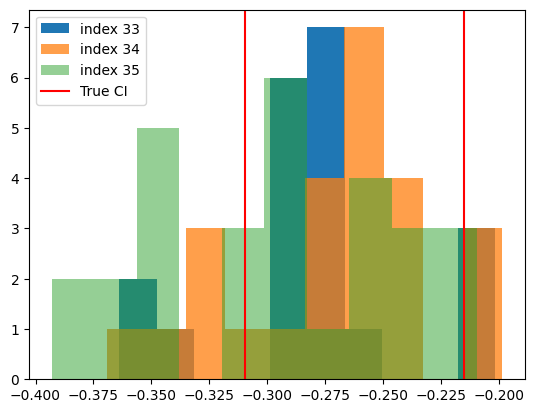

In [800]:
plt.hist(correlations_index_33, label="index 33")
plt.hist(correlations_index_34, label="index 34", alpha=0.75)
plt.hist(correlations_index_35, label="index 35", alpha=0.5)
plt.axvline(interval[0], color="red", label="True CI")
plt.axvline(interval[1], color="red")
plt.legend()
plt.show()

In [801]:
N = 1000
correlations_random_33, moments_random_33 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=N)
correlations_random_34, moments_random_34 = MOSEK_corr(OB_bounds, beta, 3, 4, obj="random", N=N)
correlations_random_35, moments_random_35 = MOSEK_corr(OB_bounds, beta, 3, 5, obj="random", N=N)

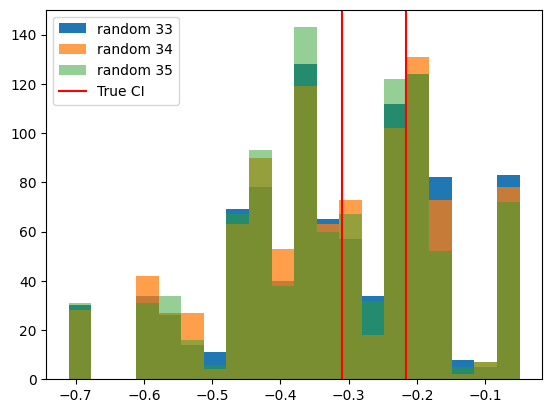

In [802]:
plt.hist(correlations_random_33, label="random 33", bins=20)
plt.hist(correlations_random_34, label="random 34", alpha=0.75, bins=20)
plt.hist(correlations_random_35, label="random 35", alpha=0.5, bins=20)
plt.axvline(interval[0], color="red", label="True CI")
plt.axvline(interval[1], color="red")
plt.legend()
plt.show()

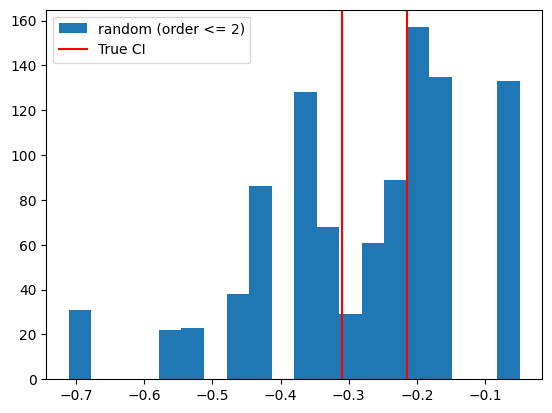

In [807]:
# random order <= 2
N = 1000
correlations_random_2, moments_random_2 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random_2", N=N)
plt.hist(correlations_random_2, label="random (order <= 2)", alpha=1, bins=20)
plt.axvline(interval[0], color="red", label="True CI")
plt.axvline(interval[1], color="red")
plt.legend()
plt.show()

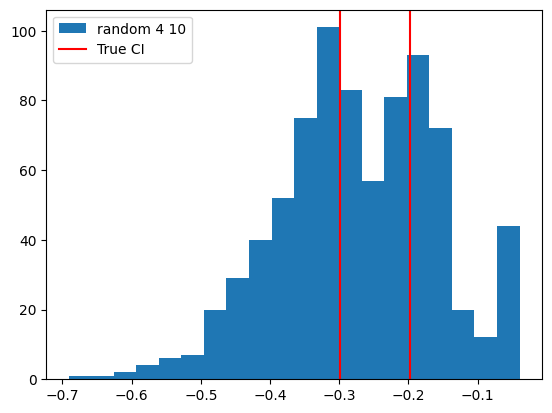

In [504]:
correlations_random, moments_random = MOSEK_corr(OB_bounds, beta, 4, 10, obj="random", N=1000)
plt.hist(correlations_random, label="random 4 10", alpha=1, bins=20)
plt.axvline(interval[0], color="red", label="True CI")
plt.axvline(interval[1], color="red")
plt.legend()
plt.show()

## Lower confidence

In [390]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 1
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N, confidence=0.5)

Mean expression 1.1215


In [391]:
# data correlation
interval = data_correlation_bootstrap(np.array(sample), confidence=0.5)

Correlation statistic -0.2420980981556574 
50% Confidence Interval (-0.258889366333638, -0.22439357181021774)


In [392]:
# single feasible point
correlation, moment = MOSEK_corr(OB_bounds, beta, 3, 4)
correlation

[-0.2274523760248313]

In [393]:
# feasible points when optimizing each variable
correlations_index_33, moments_index_33 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="index")
correlations_index_34, moments_index_34 = MOSEK_corr(OB_bounds, beta, 3, 4, obj="index")
correlations_index_35, moments_index_35 = MOSEK_corr(OB_bounds, beta, 3, 5, obj="index")

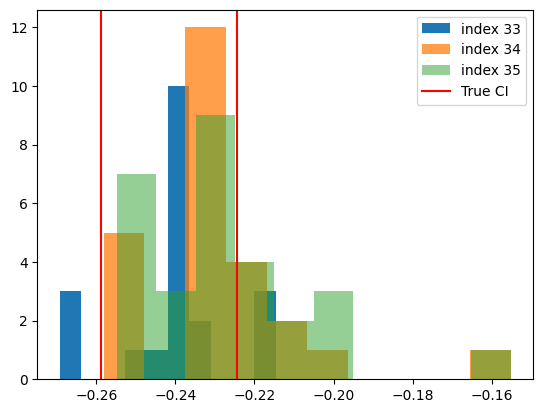

In [394]:
plt.hist(correlations_index_33, label="index 33")
plt.hist(correlations_index_34, label="index 34", alpha=0.75)
plt.hist(correlations_index_35, label="index 35", alpha=0.5)
plt.axvline(interval[0], color="red", label="True CI")
plt.axvline(interval[1], color="red")
plt.legend()
plt.show()

In [395]:
N = 1000
correlations_random_33, moments_random_33 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=N)
correlations_random_34, moments_random_34 = MOSEK_corr(OB_bounds, beta, 3, 4, obj="random", N=N)
correlations_random_35, moments_random_35 = MOSEK_corr(OB_bounds, beta, 3, 5, obj="random", N=N)

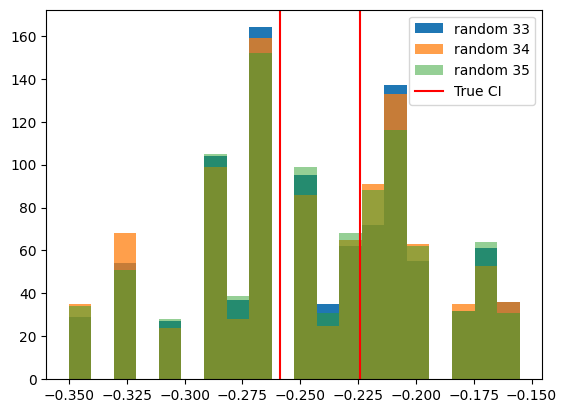

In [400]:
plt.hist(correlations_random_33, label="random 33", bins=20)
plt.hist(correlations_random_34, label="random 34", alpha=0.75, bins=20)
plt.hist(correlations_random_35, label="random 35", alpha=0.5, bins=20)
plt.axvline(interval[0], color="red", label="True CI")
plt.axvline(interval[1], color="red")
plt.legend()
plt.show()

In [364]:
# interval decreases sig. with higher confidence

In [366]:
# d_sd increase doesn't seem to have much effect

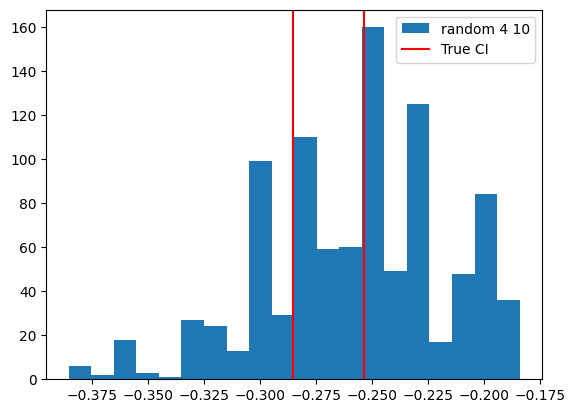

In [ ]:
correlations_random, moments_random = MOSEK_corr(OB_bounds, beta, 4, 10, obj="random", N=1000)
plt.hist(correlations_random, label="random 4 10", alpha=1, bins=20)
plt.axvline(interval[0], color="red", label="True CI")
plt.axvline(interval[1], color="red")
plt.legend()
plt.show()

## Convex combination test

In [487]:
# generate N random feasible points
correlations_random, moments_random = MOSEK_corr(OB_bounds, beta, 4, 5, obj="random", N=1000)

In [488]:
# take M random convex combinations of R random points
M = 1000
Rs = [2, 3, 5, 10]
correlations_M = [[] for R in Rs]
for i, R in enumerate(Rs):
    for m in range(M):
        # R random feasible points
        ys = rng.choice(moments_random, size=R).T
        # random point in R dim simplex
        lam = rng.exponential(scale=1, size=R)
        lam = lam / lam.sum()
        # convex combination
        ynew = np.sum(lam * ys, axis=1)
        # compute correlation
        corrnew = MOSEK_compute_feasible_correlation(5, ynew)
        # store
        correlations_M[i].append(corrnew)

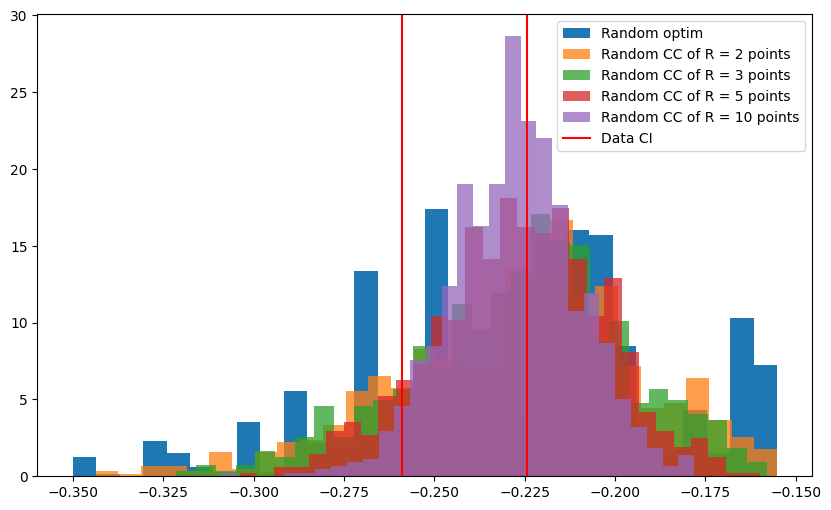

In [489]:
plt.figure(figsize=(10, 6))
plt.hist(correlations_random, label="Random optim", alpha=1, bins=30, density=True)
for i, R in enumerate(Rs):
    plt.hist(correlations_M[i], label=f"Random CC of R = {R} points", alpha=0.75, bins=30, density=True)
plt.axvline(interval[0], color="red", label="Data CI")
plt.axvline(interval[1], color="red")
plt.legend()
plt.show()

In [490]:
print(f"Data ({interval[0]}, {interval[1]})")
print(f"Optimization ({min(correlations_random)}, {max(correlations_random)})")
for i, R in enumerate(Rs):
    print(f"CC R = {R} ({min(correlations_M[i])}, {max(correlations_M[i])})")

Data (-0.258889366333638, -0.22439357181021774)
Optimization (-0.350088457194173, -0.15515034668831978)
CC R = 2 (-0.3437027609515251, -0.15515053530037956)
CC R = 3 (-0.3213389093347256, -0.1580069597214301)
CC R = 5 (-0.3038908847260907, -0.1597562722356925)
CC R = 10 (-0.3090955633644626, -0.17811474898122412)


# Pretty plots

In [685]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 1
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N, confidence=0.95)

Mean expression 1.1105


In [686]:
# data correlation
interval = data_correlation_bootstrap(np.array(sample), confidence=0.95)

Correlation statistic -0.2505645193441154 
95% Confidence Interval (-0.2983960559070701, -0.20155421366815066)


In [687]:
# single feasible point
correlation, moment = MOSEK_corr(OB_bounds, beta, 3, 3)
correlation

[-0.2681349266584495]

In [688]:
# feasible moment
moment

[array([1.        , 1.13811476, 1.08272211, 2.41746307, 0.91640393,
        2.40887009, 6.68447635, 1.72994557, 1.8551932 , 7.0131485 ])]

In [689]:
# optimizing variables
correlations_index, moments_index = MOSEK_corr(OB_bounds, beta, 3, 3, obj="index")

In [690]:
# optimizing random objectives
correlations_random_100, moments_random_100 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=100)
correlations_random_1000, moments_random_1000 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=1000)
correlations_random_10000, moments_random_10000 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=10000)

In [691]:
# convex combinations
# take M random convex combinations of R random points
M = 1000
Rs = [2, 3, 5]#, 10]
correlations_M = [[] for R in Rs]
for i, R in enumerate(Rs):
    for m in range(M):
        # R random feasible points
        ys = rng.choice(moments_random_1000, size=R).T
        # random point in R dim simplex
        lam = rng.exponential(scale=1, size=R)
        lam = lam / lam.sum()
        # convex combination
        ynew = np.sum(lam * ys, axis=1)
        # compute correlation
        corrnew = MOSEK_compute_feasible_correlation(5, ynew)
        # store
        correlations_M[i].append(corrnew)

In [692]:
# higher d_sd (random objectives)
correlations_random_dsd, moments_random_dsd = MOSEK_corr(OB_bounds, beta, 3, 10, obj="random", N=1000)

In [693]:
def txt_int(correlation):
    mn = round(min(correlation), 2)
    mx = round(max(correlation), 2)
    return f"({mn}, {mx})"

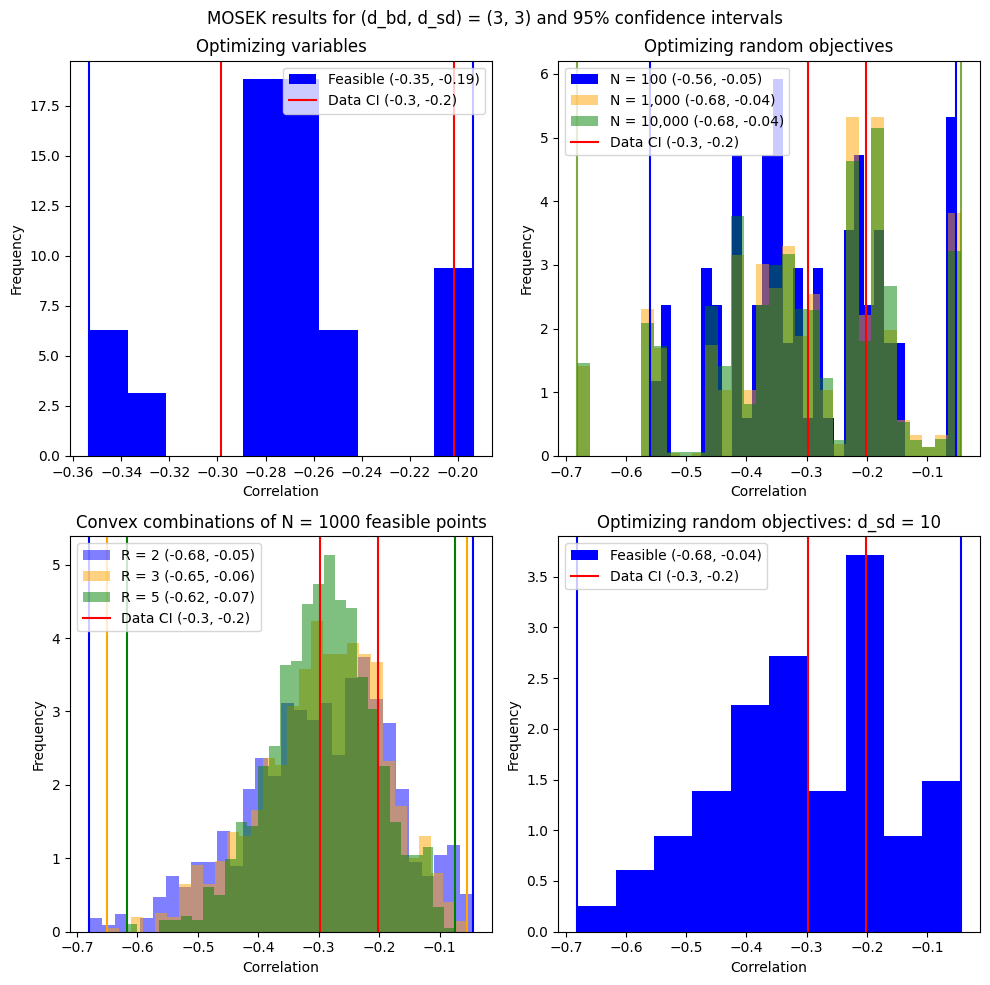

In [694]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
# optimizing variables
axs[0, 0].hist(correlations_index, density=True, color="blue", label=f"Feasible {txt_int(correlations_index)}")
axs[0, 0].axvline(min(correlations_index), color="blue")
axs[0, 0].axvline(max(correlations_index), color="blue")
axs[0, 0].axvline(interval[0], color="red", label=f"Data CI {txt_int(interval)}")
axs[0, 0].axvline(interval[1], color="red")
axs[0, 0].set_title("Optimizing variables")
axs[0, 0].set_xlabel("Correlation")
axs[0, 0].set_ylabel("Frequency")
axs[0, 0].legend()
# optimizing random objectives
axs[0, 1].hist(correlations_random_100, density=True, color="blue", bins=30, label=f"N = 100 {txt_int(correlations_random_100)}")
axs[0, 1].axvline(min(correlations_random_100), color="blue")
axs[0, 1].axvline(max(correlations_random_100), color="blue")
axs[0, 1].hist(correlations_random_1000, density=True, color="orange", bins=30, label=f"N = 1,000 {txt_int(correlations_random_1000)}", alpha=0.5)
axs[0, 1].axvline(min(correlations_random_1000), color="orange", alpha=0.5)
axs[0, 1].axvline(max(correlations_random_1000), color="orange", alpha=0.5)
axs[0, 1].hist(correlations_random_10000, density=True, color="green", bins=30, label=f"N = 10,000 {txt_int(correlations_random_10000)}", alpha=0.5)
axs[0, 1].axvline(min(correlations_random_10000), color="green", alpha=0.5)
axs[0, 1].axvline(max(correlations_random_10000), color="green", alpha=0.5)
axs[0, 1].axvline(interval[0], color="red", label=f"Data CI {txt_int(interval)}")
axs[0, 1].axvline(interval[1], color="red")
axs[0, 1].set_title("Optimizing random objectives")
axs[0, 1].set_xlabel("Correlation")
axs[0, 1].set_ylabel("Frequency")
axs[0, 1].legend()
# convex combinations
colors = ["blue", "orange", "green"]#, "purple"]
for i, R in enumerate(Rs):
    axs[1, 0].hist(correlations_M[i], label=f"R = {R} {txt_int(correlations_M[i])}", alpha=0.5, bins=30, density=True, color=colors[i])
    axs[1, 0].axvline(min(correlations_M[i]), color=colors[i])
    axs[1, 0].axvline(max(correlations_M[i]), color=colors[i])
axs[1, 0].axvline(interval[0], color="red", label=f"Data CI {txt_int(interval)}")
axs[1, 0].axvline(interval[1], color="red")
axs[1, 0].set_title("Convex combinations of N = 1000 feasible points")
axs[1, 0].set_xlabel("Correlation")
axs[1, 0].set_ylabel("Frequency")
axs[1, 0].legend()
# optimizing variables
axs[1, 1].hist(correlations_random_dsd, density=True, color="blue", label=f"Feasible {txt_int(correlations_random_dsd)}")
axs[1, 1].axvline(min(correlations_random_dsd), color="blue")
axs[1, 1].axvline(max(correlations_random_dsd), color="blue")
axs[1, 1].axvline(interval[0], color="red", label=f"Data CI {txt_int(interval)}")
axs[1, 1].axvline(interval[1], color="red")
axs[1, 1].set_title("Optimizing random objectives: d_sd = 10")
axs[1, 1].set_xlabel("Correlation")
axs[1, 1].set_ylabel("Frequency")
axs[1, 1].legend()
plt.suptitle("MOSEK results for (d_bd, d_sd) = (3, 3) and 95% confidence intervals")
plt.tight_layout()
plt.show()

### Lower confidence

In [ ]:
# bootstrap
OB_bounds = bootstrap(downsample, d_boot, 1000, confidence=0.5)

In [696]:
# data correlation
interval = data_correlation_bootstrap(np.array(sample), confidence=0.5)

Correlation statistic -0.2505645193441154 
50% Confidence Interval (-0.2672996069511153, -0.23443681553873277)


In [697]:
# single feasible point
correlation, moment = MOSEK_corr(OB_bounds, beta, 3, 3)
correlation

[-0.2517274955792082]

In [698]:
# feasible moment
moment

[array([1.        , 1.13934485, 1.0847931 , 2.46835897, 0.92599678,
        2.47234678, 6.72018647, 1.72119973, 1.84160861, 7.12745211])]

In [699]:
# optimizing variables
correlations_index, moments_index = MOSEK_corr(OB_bounds, beta, 3, 3, obj="index")

In [700]:
# optimizing random objectives
correlations_random_100, moments_random_100 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=100)
correlations_random_1000, moments_random_1000 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=1000)
correlations_random_10000, moments_random_10000 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=10000)

In [701]:
# convex combinations
# take M random convex combinations of R random points
M = 1000
Rs = [2, 3, 5]#, 10]
correlations_M = [[] for R in Rs]
for i, R in enumerate(Rs):
    for m in range(M):
        # R random feasible points
        ys = rng.choice(moments_random_1000, size=R).T
        # random point in R dim simplex
        lam = rng.exponential(scale=1, size=R)
        lam = lam / lam.sum()
        # convex combination
        ynew = np.sum(lam * ys, axis=1)
        # compute correlation
        corrnew = MOSEK_compute_feasible_correlation(5, ynew)
        # store
        correlations_M[i].append(corrnew)

In [702]:
# higher d_sd (random objectives)
correlations_random_dsd, moments_random_dsd = MOSEK_corr(OB_bounds, beta, 3, 10, obj="random", N=1000)

In [703]:
def txt_int(correlation):
    mn = round(min(correlation), 2)
    mx = round(max(correlation), 2)
    return f"({mn}, {mx})"

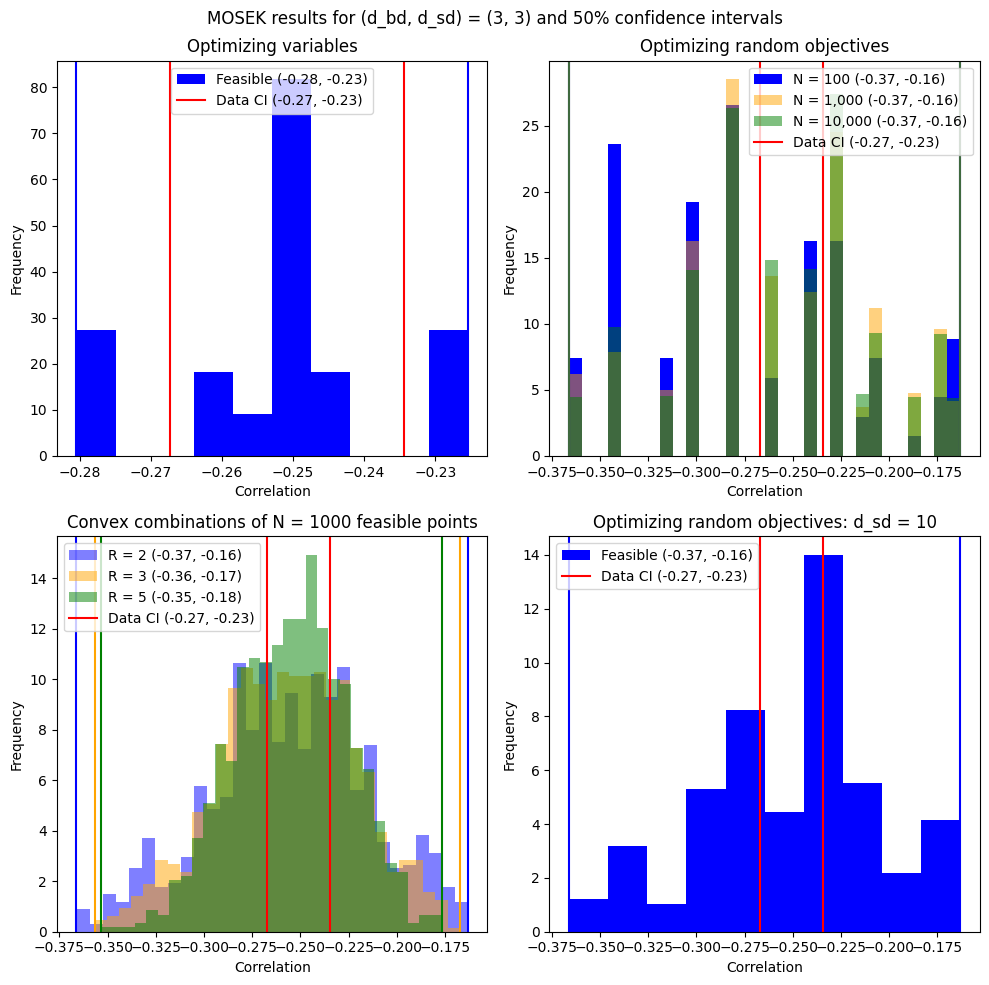

In [704]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
# optimizing variables
axs[0, 0].hist(correlations_index, density=True, color="blue", label=f"Feasible {txt_int(correlations_index)}")
axs[0, 0].axvline(min(correlations_index), color="blue")
axs[0, 0].axvline(max(correlations_index), color="blue")
axs[0, 0].axvline(interval[0], color="red", label=f"Data CI {txt_int(interval)}")
axs[0, 0].axvline(interval[1], color="red")
axs[0, 0].set_title("Optimizing variables")
axs[0, 0].set_xlabel("Correlation")
axs[0, 0].set_ylabel("Frequency")
axs[0, 0].legend()
# optimizing random objectives
axs[0, 1].hist(correlations_random_100, density=True, color="blue", bins=30, label=f"N = 100 {txt_int(correlations_random_100)}")
axs[0, 1].axvline(min(correlations_random_100), color="blue")
axs[0, 1].axvline(max(correlations_random_100), color="blue")
axs[0, 1].hist(correlations_random_1000, density=True, color="orange", bins=30, label=f"N = 1,000 {txt_int(correlations_random_1000)}", alpha=0.5)
axs[0, 1].axvline(min(correlations_random_1000), color="orange", alpha=0.5)
axs[0, 1].axvline(max(correlations_random_1000), color="orange", alpha=0.5)
axs[0, 1].hist(correlations_random_10000, density=True, color="green", bins=30, label=f"N = 10,000 {txt_int(correlations_random_10000)}", alpha=0.5)
axs[0, 1].axvline(min(correlations_random_10000), color="green", alpha=0.5)
axs[0, 1].axvline(max(correlations_random_10000), color="green", alpha=0.5)
axs[0, 1].axvline(interval[0], color="red", label=f"Data CI {txt_int(interval)}")
axs[0, 1].axvline(interval[1], color="red")
axs[0, 1].set_title("Optimizing random objectives")
axs[0, 1].set_xlabel("Correlation")
axs[0, 1].set_ylabel("Frequency")
axs[0, 1].legend()
# convex combinations
colors = ["blue", "orange", "green"]#, "purple"]
for i, R in enumerate(Rs):
    axs[1, 0].hist(correlations_M[i], label=f"R = {R} {txt_int(correlations_M[i])}", alpha=0.5, bins=30, density=True, color=colors[i])
    axs[1, 0].axvline(min(correlations_M[i]), color=colors[i])
    axs[1, 0].axvline(max(correlations_M[i]), color=colors[i])
axs[1, 0].axvline(interval[0], color="red", label=f"Data CI {txt_int(interval)}")
axs[1, 0].axvline(interval[1], color="red")
axs[1, 0].set_title("Convex combinations of N = 1000 feasible points")
axs[1, 0].set_xlabel("Correlation")
axs[1, 0].set_ylabel("Frequency")
axs[1, 0].legend()
# optimizing variables
axs[1, 1].hist(correlations_random_dsd, density=True, color="blue", label=f"Feasible {txt_int(correlations_random_dsd)}")
axs[1, 1].axvline(min(correlations_random_dsd), color="blue")
axs[1, 1].axvline(max(correlations_random_dsd), color="blue")
axs[1, 1].axvline(interval[0], color="red", label=f"Data CI {txt_int(interval)}")
axs[1, 1].axvline(interval[1], color="red")
axs[1, 1].set_title("Optimizing random objectives: d_sd = 10")
axs[1, 1].set_xlabel("Correlation")
axs[1, 1].set_ylabel("Frequency")
axs[1, 1].legend()
plt.suptitle("MOSEK results for (d_bd, d_sd) = (3, 3) and 50% confidence intervals")
plt.tight_layout()
plt.show()

# Real data example

In [808]:
# read fibroblast transcript counts
data_FIB = pd.read_csv("../Real-Data-2/Data/GSE151334_FIB_counts_thresh.csv", index_col=0)

# load capture
beta = np.loadtxt("../Real-Data-2/Capture/beta_FIB.txt")

# load RNA types
biotypes_dict = json.load(open("../Real-Data-2/Biotypes/biotypes_FIB.json"))

# select indices of protein coding mRNA and non-coding miRNA
pcRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "protein_coding"]
miRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "miRNA"]

# separate data
data_FIB_pcRNA = data_FIB.iloc[pcRNA_indices]
data_FIB_miRNA = data_FIB.iloc[miRNA_indices]

In [809]:
# select
miRNA = "MIR100"
mRNA_idx = 1

# construct sample
sample_miRNA = data_FIB_miRNA.loc[miRNA]
sample_mRNA = data_FIB_pcRNA.iloc[mRNA_idx]
sample = list(zip(sample_miRNA, sample_mRNA))

In [810]:
# (observed) data correlation
interval = data_correlation_bootstrap(np.array(sample), confidence=0.95)

Correlation statistic 0.06778759988545108 
95% Confidence Interval (-0.023579727664825224, 0.22519384583021476)


In [811]:
# order
d_boot = 4

# bootstrap
OB_bounds = bootstrap(sample, d_boot, 1000, confidence=0.95)

In [812]:
# single feasible point
correlation, moment = MOSEK_corr(OB_bounds, beta, 3, 3)
correlation

[-0.044110089591606234]

In [813]:
# optimizing variables
correlations_index, moments_index = MOSEK_corr(OB_bounds, beta, 3, 3, obj="index")

In [814]:
# optimizing random objectives
correlations_random_100, moments_random_100 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=100)
correlations_random_1000, moments_random_1000 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=1000)
correlations_random_10000, moments_random_10000 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=10000)

In [815]:
# optimizing random objectives (order <= 2 moments)
correlations_random_2_100, moments_random_2_100 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random_2", N=100)
correlations_random_2_1000, moments_random_2_1000 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random_2", N=1000)
correlations_random_2_10000, moments_random_2_10000 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random_2", N=10000)

In [816]:
# convex combinations
# take M random convex combinations of R random points
M = 1000
Rs = [2, 3, 5]#, 10]
correlations_M = [[] for R in Rs]
for i, R in enumerate(Rs):
    for m in range(M):
        # R random feasible points
        ys = rng.choice(moments_random_1000, size=R).T
        # random point in R dim simplex
        lam = rng.exponential(scale=1, size=R)
        lam = lam / lam.sum()
        # convex combination
        ynew = np.sum(lam * ys, axis=1)
        # compute correlation
        corrnew = MOSEK_compute_feasible_correlation(5, ynew)
        # store
        correlations_M[i].append(corrnew)

In [817]:
# higher d_sd (random objectives)
correlations_random_dsd, moments_random_dsd = MOSEK_corr(OB_bounds, beta, 3, 5, obj="random", N=1000)

In [818]:
feasible_per = round(len(correlations_random_dsd) / 1000, 2)
feasible_per

0.2

In [828]:
# higher d_sd (random objectives, order <= 2)
correlations_random_2_dsd, moments_random_2_dsd = MOSEK_corr(OB_bounds, beta, 3, 5, obj="random_2", N=1000)

SolutionError: Solution status is Unknown but Optimal is expected. Reason: Accessing interior-point solution whose problem status is Unknown.

In [ ]:
feasible_2_per = round(len(correlations_random_2_dsd) / 1000, 2)
feasible_2_per

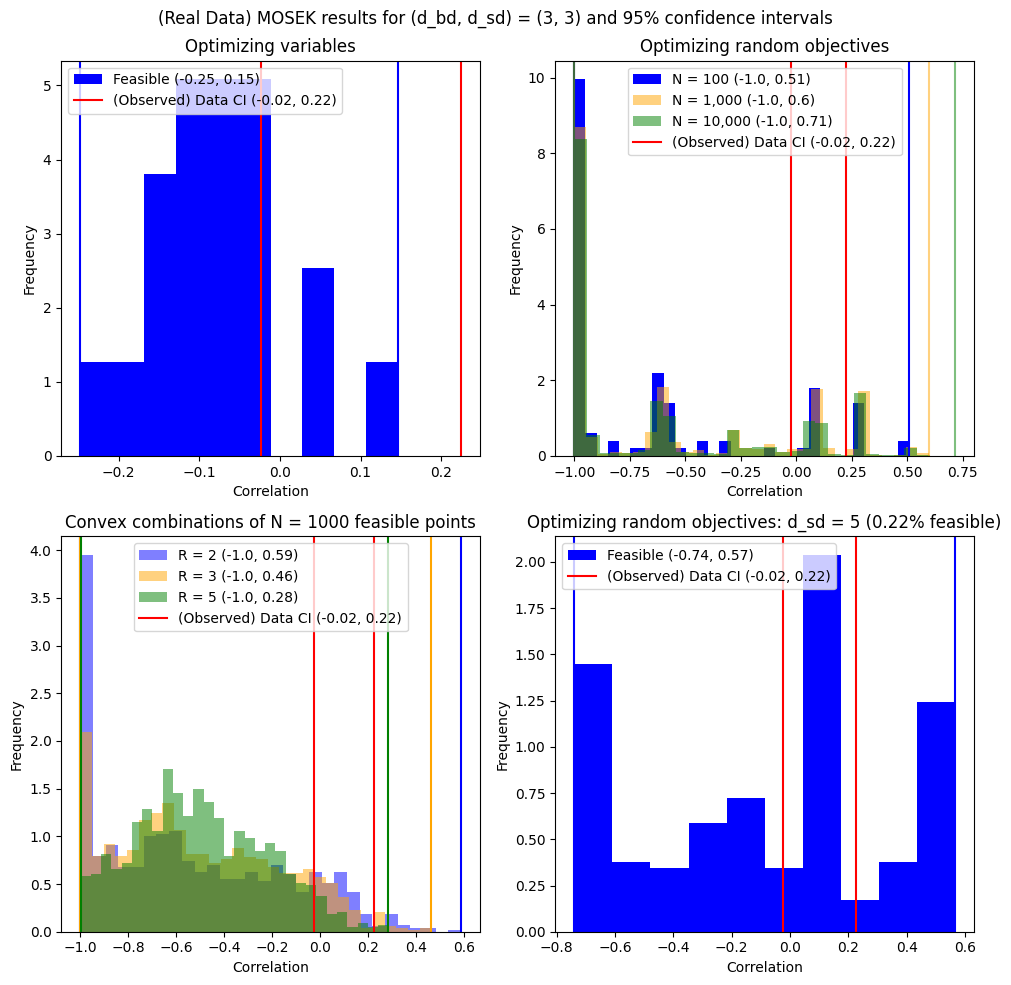

In [784]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
# optimizing variables
axs[0, 0].hist(correlations_index, density=True, color="blue", label=f"Feasible {txt_int(correlations_index)}")
axs[0, 0].axvline(min(correlations_index), color="blue")
axs[0, 0].axvline(max(correlations_index), color="blue")
axs[0, 0].axvline(interval[0], color="red", label=f"(Observed) Data CI {txt_int(interval)}")
axs[0, 0].axvline(interval[1], color="red")
axs[0, 0].set_title("Optimizing variables")
axs[0, 0].set_xlabel("Correlation")
axs[0, 0].set_ylabel("Frequency")
axs[0, 0].legend()
# optimizing random objectives
axs[0, 1].hist(correlations_random_100, density=True, color="blue", bins=30, label=f"N = 100 {txt_int(correlations_random_100)}")
axs[0, 1].axvline(min(correlations_random_100), color="blue")
axs[0, 1].axvline(max(correlations_random_100), color="blue")
axs[0, 1].hist(correlations_random_1000, density=True, color="orange", bins=30, label=f"N = 1,000 {txt_int(correlations_random_1000)}", alpha=0.5)
axs[0, 1].axvline(min(correlations_random_1000), color="orange", alpha=0.5)
axs[0, 1].axvline(max(correlations_random_1000), color="orange", alpha=0.5)
axs[0, 1].hist(correlations_random_10000, density=True, color="green", bins=30, label=f"N = 10,000 {txt_int(correlations_random_10000)}", alpha=0.5)
axs[0, 1].axvline(min(correlations_random_10000), color="green", alpha=0.5)
axs[0, 1].axvline(max(correlations_random_10000), color="green", alpha=0.5)
axs[0, 1].axvline(interval[0], color="red", label=f"(Observed) Data CI {txt_int(interval)}")
axs[0, 1].axvline(interval[1], color="red")
axs[0, 1].set_title("Optimizing random objectives")
axs[0, 1].set_xlabel("Correlation")
axs[0, 1].set_ylabel("Frequency")
axs[0, 1].legend()
# convex combinations
colors = ["blue", "orange", "green"]#, "purple"]
for i, R in enumerate(Rs):
    axs[1, 0].hist(correlations_M[i], label=f"R = {R} {txt_int(correlations_M[i])}", alpha=0.5, bins=30, density=True, color=colors[i])
    axs[1, 0].axvline(min(correlations_M[i]), color=colors[i])
    axs[1, 0].axvline(max(correlations_M[i]), color=colors[i])
axs[1, 0].axvline(interval[0], color="red", label=f"(Observed) Data CI {txt_int(interval)}")
axs[1, 0].axvline(interval[1], color="red")
axs[1, 0].set_title("Convex combinations of N = 1000 feasible points")
axs[1, 0].set_xlabel("Correlation")
axs[1, 0].set_ylabel("Frequency")
axs[1, 0].legend()
# optimizing variables
axs[1, 1].hist(correlations_random_dsd, density=True, color="blue", label=f"Feasible {txt_int(correlations_random_dsd)}")
axs[1, 1].axvline(min(correlations_random_dsd), color="blue")
axs[1, 1].axvline(max(correlations_random_dsd), color="blue")
axs[1, 1].axvline(interval[0], color="red", label=f"(Observed) Data CI {txt_int(interval)}")
axs[1, 1].axvline(interval[1], color="red")
axs[1, 1].set_title(f"Optimizing random objectives: d_sd = 5 ({feasible_per}% feasible)")
axs[1, 1].set_xlabel("Correlation")
axs[1, 1].set_ylabel("Frequency")
axs[1, 1].legend()
plt.suptitle("(Real Data) MOSEK results for (d_bd, d_sd) = (3, 3) and 95% confidence intervals")
plt.tight_layout()
plt.show()

### Lower confidence

In [785]:
# (observed) data correlation
interval = data_correlation_bootstrap(np.array(sample), confidence=0.5)

Correlation statistic 0.06778759988545108 
50% Confidence Interval (0.0354259811170004, 0.11775041829308928)


In [786]:
# order
d_boot = 4

# bootstrap
OB_bounds = bootstrap(sample, d_boot, 1000, confidence=0.5)

In [787]:
# single feasible point
correlation, moment = MOSEK_corr(OB_bounds, beta, 3, 3)
correlation

[0.015451293997752299]

In [788]:
# optimizing variables
correlations_index, moments_index = MOSEK_corr(OB_bounds, beta, 3, 3, obj="index")

In [789]:
# optimizing random objectives
correlations_random_100, moments_random_100 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=100)
correlations_random_1000, moments_random_1000 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=1000)
correlations_random_10000, moments_random_10000 = MOSEK_corr(OB_bounds, beta, 3, 3, obj="random", N=10000)

In [790]:
# convex combinations
# take M random convex combinations of R random points
M = 1000
Rs = [2, 3, 5]#, 10]
correlations_M = [[] for R in Rs]
for i, R in enumerate(Rs):
    for m in range(M):
        # R random feasible points
        ys = rng.choice(moments_random_1000, size=R).T
        # random point in R dim simplex
        lam = rng.exponential(scale=1, size=R)
        lam = lam / lam.sum()
        # convex combination
        ynew = np.sum(lam * ys, axis=1)
        # compute correlation
        corrnew = MOSEK_compute_feasible_correlation(5, ynew)
        # store
        correlations_M[i].append(corrnew)

In [ ]:
# higher d_sd (random objectives)
correlations_random_dsd, moments_random_dsd = MOSEK_corr(OB_bounds, beta, 3, 5, obj="random", N=1000)

In [792]:
feasible_per = round(len(correlations_random_dsd) / 1000, 2)
feasible_per

0.04

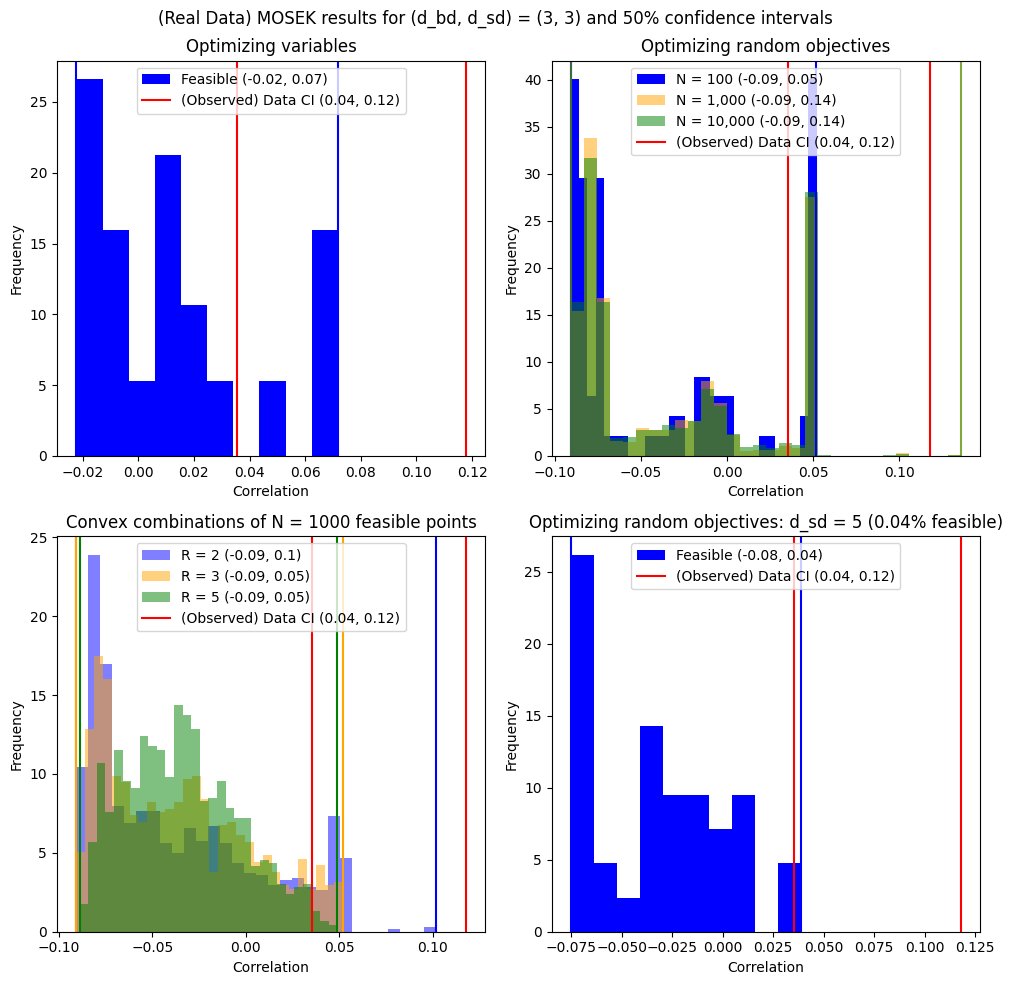

In [793]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
# optimizing variables
axs[0, 0].hist(correlations_index, density=True, color="blue", label=f"Feasible {txt_int(correlations_index)}")
axs[0, 0].axvline(min(correlations_index), color="blue")
axs[0, 0].axvline(max(correlations_index), color="blue")
axs[0, 0].axvline(interval[0], color="red", label=f"(Observed) Data CI {txt_int(interval)}")
axs[0, 0].axvline(interval[1], color="red")
axs[0, 0].set_title("Optimizing variables")
axs[0, 0].set_xlabel("Correlation")
axs[0, 0].set_ylabel("Frequency")
axs[0, 0].legend()
# optimizing random objectives
axs[0, 1].hist(correlations_random_100, density=True, color="blue", bins=30, label=f"N = 100 {txt_int(correlations_random_100)}")
axs[0, 1].axvline(min(correlations_random_100), color="blue")
axs[0, 1].axvline(max(correlations_random_100), color="blue")
axs[0, 1].hist(correlations_random_1000, density=True, color="orange", bins=30, label=f"N = 1,000 {txt_int(correlations_random_1000)}", alpha=0.5)
axs[0, 1].axvline(min(correlations_random_1000), color="orange", alpha=0.5)
axs[0, 1].axvline(max(correlations_random_1000), color="orange", alpha=0.5)
axs[0, 1].hist(correlations_random_10000, density=True, color="green", bins=30, label=f"N = 10,000 {txt_int(correlations_random_10000)}", alpha=0.5)
axs[0, 1].axvline(min(correlations_random_10000), color="green", alpha=0.5)
axs[0, 1].axvline(max(correlations_random_10000), color="green", alpha=0.5)
axs[0, 1].axvline(interval[0], color="red", label=f"(Observed) Data CI {txt_int(interval)}")
axs[0, 1].axvline(interval[1], color="red")
axs[0, 1].set_title("Optimizing random objectives")
axs[0, 1].set_xlabel("Correlation")
axs[0, 1].set_ylabel("Frequency")
axs[0, 1].legend()
# convex combinations
colors = ["blue", "orange", "green"]#, "purple"]
for i, R in enumerate(Rs):
    axs[1, 0].hist(correlations_M[i], label=f"R = {R} {txt_int(correlations_M[i])}", alpha=0.5, bins=30, density=True, color=colors[i])
    axs[1, 0].axvline(min(correlations_M[i]), color=colors[i])
    axs[1, 0].axvline(max(correlations_M[i]), color=colors[i])
axs[1, 0].axvline(interval[0], color="red", label=f"(Observed) Data CI {txt_int(interval)}")
axs[1, 0].axvline(interval[1], color="red")
axs[1, 0].set_title("Convex combinations of N = 1000 feasible points")
axs[1, 0].set_xlabel("Correlation")
axs[1, 0].set_ylabel("Frequency")
axs[1, 0].legend()
# optimizing variables
axs[1, 1].hist(correlations_random_dsd, density=True, color="blue", label=f"Feasible {txt_int(correlations_random_dsd)}")
axs[1, 1].axvline(min(correlations_random_dsd), color="blue")
axs[1, 1].axvline(max(correlations_random_dsd), color="blue")
axs[1, 1].axvline(interval[0], color="red", label=f"(Observed) Data CI {txt_int(interval)}")
axs[1, 1].axvline(interval[1], color="red")
axs[1, 1].set_title(f"Optimizing random objectives: d_sd = 5 ({feasible_per}% feasible)")
axs[1, 1].set_xlabel("Correlation")
axs[1, 1].set_ylabel("Frequency")
axs[1, 1].legend()
plt.suptitle("(Real Data) MOSEK results for (d_bd, d_sd) = (3, 3) and 50% confidence intervals")
plt.tight_layout()
plt.show()

# Order effects

In [26]:
from SDP_interaction_inference.simulation import gillespie_birth_death

In [291]:
def MOSEK_order(OB_bounds, beta, d_bd, d_sd):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)

    with Model('MOSEK-SDP') as md: 

        # variables
        y = md.variable('y', Nd, Domain.greaterThan(0.))

        # variable dict
        variables = {
            'y': y
        }

        # moment matrices
        for s in range(S + 1):

            # restrict to d_sd
            M_s = MOSEK_construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s

            # PSD
            md.constraint(f'M_{s}_PSD', M_s == Domain.inPSDCone())

        # moment bounds

        # get CI bounds on OB moments (up to order d_bd)
        y_lb = OB_bounds[0, :Nbd]
        y_ub = OB_bounds[1, :Nbd]

        # B scaling matrix
        B = compute_B(beta, S, U, d_bd)

        # moment bounds
        md.constraint('y_UB', B @ y[:Nbd] <= y_ub)
        md.constraint('y_LB', B @ y[:Nbd] >= y_lb)

        # fixed moment
        md.constraint('y0', y[0] == 1)

        # collect minima and maxima
        minima = []
        maxima = []

        # optimize variables
        for i in range(Nd):
            try:
                md.objective(ObjectiveSense.Minimize, y[i])
                md.solve()
                minima.append(md.primalObjValue())
            except SolutionError:
                minima.append(None)
            try:
                md.objective(ObjectiveSense.Maximize, y[i])
                md.solve()
                maxima.append(md.primalObjValue())
            except:
                maxima.append(None)
        
    return minima, maxima

In [317]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 0.5
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N, confidence=0.95)

Mean expression 0.554


### Increasing d_sd > d_bd

Text(0.5, 1.0, 'Feasible moment values: effect of order (d_bd, d_sd)')

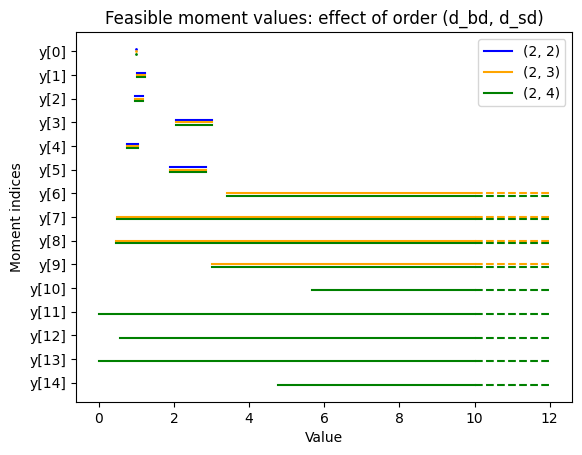

In [ ]:
orders = [(2, 2), (2, 3), (2, 4)]
offsets = [0.1, 0, -0.1]
colors = ["blue", "orange", "green"]
labels=["(2, 2)", "(2, 3)", "(2, 4)"]
K = 10
minimas = []
maximas = []

for i, (d_bd, d_sd) in enumerate(orders):
    label = labels[i]
    minima, maxima = MOSEK_order(OB_bounds, beta, d_bd, d_sd)
    minimas.append(minima)
    maximas.append(maxima)
    for j, (mn, mx) in enumerate(zip(minima, maxima)):
        if mx is None:
            mx = K
            plt.plot([K, K + 2], [-j + offsets[i], -j + offsets[i]], color=colors[i], linestyle="--")
        if mn == mx: # y[0] = 1
            plt.scatter([mn], [-j + offsets[i]], color=colors[i], s=1)
        plt.plot([mn, mx], [-j + offsets[i], -j + offsets[i]], color=colors[i], label=label)
        label=None
plt.legend()
plt.yticks([-i for i in range(len(minima))], [f'y[{i}]' for i in range(len(minima))])
plt.ylabel("Moment indices")
plt.xlabel("Value")
plt.title("Feasible moment values: effect of order (d_bd, d_sd)")

See that increasing d_sd does not impact the bounds on exisiting <= d_bd order moments

Graph zoomed out but values below show only small numerical variability, no actual change.

In [319]:
for i in range(len(minimas[0])):
    print(minimas[1][i] - minimas[0][i], maximas[1][i] - maximas[0][i])

0.0 0.0
-5.268052660767353e-11 -8.96534446681585e-09
-4.256583974182604e-11 -1.7098382043556626e-08
-8.562928144328907e-12 8.597256240250317e-11
1.375788372115494e-12 -6.566391874684996e-10
-1.326050380612287e-12 2.1735413469059495e-10


In [321]:
for i in range(len(minimas[0])):
    print(minimas[2][i] - minimas[0][i], maximas[2][i] - maximas[0][i])

0.0 0.0
6.60934129648183e-09 -3.3573144264664734e-12
2.5190999286550664e-09 -2.226663298188214e-12
-8.488365565995082e-11 1.0940892636313038e-10
-4.533928787964214e-12 -6.23945339839338e-14
-4.763101024707339e-10 2.4347990290607413e-10


In [322]:
for i in range(len(minimas[0]), len(minimas[1])):
    print(minimas[2][i] - minimas[1][i])

-1.0600604749555487e-07
9.957482727251943e-09
5.230545885304139e-09
1.0955110374410992e-07


### Increasing d

Text(0.5, 1.0, 'Feasible moment values: effect of order (d_bd, d_sd)')

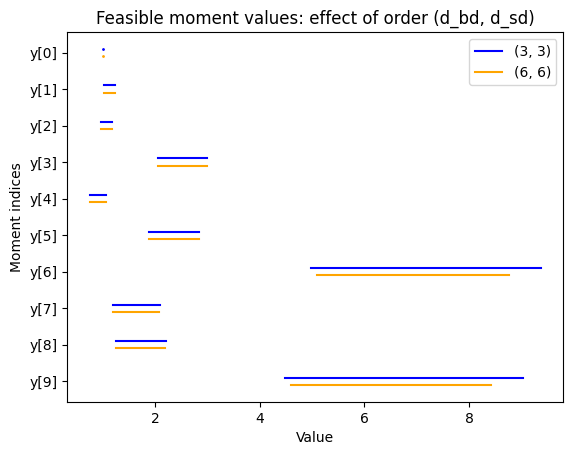

In [331]:
orders = [(3, 3), (6, 6)]
offsets = [0.1, -0.1]
colors = ["blue", "orange"]
labels=["(3, 3)", "(6, 6)"]
M = 9
K = 10
minimas = []
maximas = []

for i, (d_bd, d_sd) in enumerate(orders):
    label = labels[i]
    minima, maxima = MOSEK_order(OB_bounds, beta, d_bd, d_sd)
    minimas.append(minima)
    maximas.append(maxima)
    for j, (mn, mx) in enumerate(zip(minima, maxima)):
        if j > M: break
        if mx is None:
            mx = K
            plt.plot([K, K + 2], [-j + offsets[i], -j + offsets[i]], color=colors[i], linestyle="--")
        if mn == mx: # y[0] = 1
            plt.scatter([mn], [-j + offsets[i]], color=colors[i], s=1)
        plt.plot([mn, mx], [-j + offsets[i], -j + offsets[i]], color=colors[i], label=label)
        label=None
plt.legend()
plt.yticks([-i for i in range(M + 1)], [f'y[{i}]' for i in range(M + 1)])
plt.ylabel("Moment indices")
plt.xlabel("Value")
plt.title("Feasible moment values: effect of order (d_bd, d_sd)")

Does improve bounds, sometimes very small improvement and hard to see on plot

However, values below show clearly different situation to d_sd above, with changes on the order of e-2 for lower order moments, significantly increasing in size for higher order moments

In [332]:
for i in range(len(minimas[0])):
    print(minimas[1][i] - minimas[0][i], maximas[1][i] - maximas[0][i])

0.0 0.0
6.467293367506954e-11 3.26183524634871e-13
4.1325942667924664e-11 1.3236078899581116e-12
4.3807713012711247e-10 -0.0021247532725459095
3.354949651424022e-11 -3.846717167022007e-09
7.316398598078422e-10 -0.0008116709634715669
0.11062040585319899 -0.6136155828406036
1.9087709191012436e-10 -0.02485792099692885
3.645972412869014e-12 -0.01885330769655358
0.10006665302032136 -0.6035638197212005


### No SDP

In [336]:
def MOSEK_noSDP(OB_bounds, beta, d):

    # helpful values
    S = 2
    Nd = compute_Nd(S, d)

    with Model('MOSEK-SDP') as md: 

        # variables
        y = md.variable('y', Nd, Domain.greaterThan(0.))

        # variable dict
        variables = {
            'y': y
        }

        # get CI bounds on OB moments (up to order d_bd)
        y_lb = OB_bounds[0, :Nd]
        y_ub = OB_bounds[1, :Nd]

        # B scaling matrix
        B = compute_B(beta, S, U, d)

        # moment bounds
        md.constraint('y_UB', B @ y <= y_ub)
        md.constraint('y_LB', B @ y >= y_lb)

        # fixed moment
        md.constraint('y0', y[0] == 1)

        # collect minima and maxima
        minima = []
        maxima = []

        # optimize variables
        for i in range(Nd):
            try:
                md.objective(ObjectiveSense.Minimize, y[i])
                md.solve()
                minima.append(md.primalObjValue())
            except SolutionError:
                minima.append(None)
            try:
                md.objective(ObjectiveSense.Maximize, y[i])
                md.solve()
                maxima.append(md.primalObjValue())
            except:
                maxima.append(None)
        
    return minima, maxima

Text(0.5, 1.0, 'Feasible moment values: no SDP')

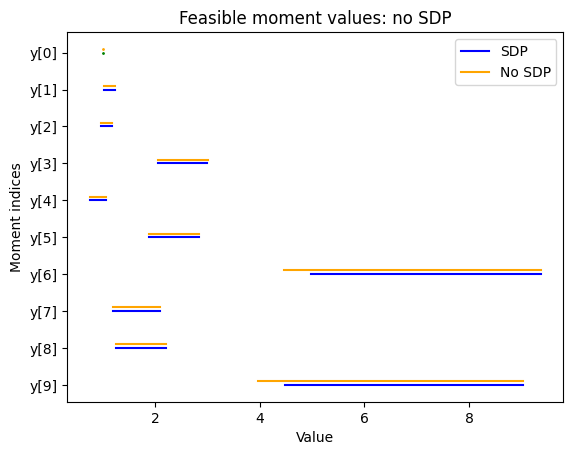

In [342]:
d = 3
K = 10

minima, maxima = MOSEK_order(OB_bounds, beta, d, d)
label = "SDP"
for j, (mn, mx) in enumerate(zip(minima, maxima)):
    if mx is None:# or mx > K:
        mx = K
        plt.plot([K, K + 2], [-j, -j], color="blue", linestyle="--")
    if mn == mx: # y[0] = 1
        plt.scatter([mn], [-j], color=colors[i], s=1)
    plt.plot([mn, mx], [-j, -j], color="blue", label=label)
    label = None

minima_no, maxima_no = MOSEK_noSDP(OB_bounds, beta, d)
label = "No SDP"
for j, (mn, mx) in enumerate(zip(minima_no, maxima_no)):
    if mx is None:# or mx > K:
        mx = K
        plt.plot([K, K + 2], [-j + 0.1, -j + 0.1], color="orange", linestyle="--")
    if mn == mx: # y[0] = 1
        plt.scatter([mn], [-j + 0.1], color="orange", s=1)
    plt.plot([mn, mx], [-j + 0.1, -j + 0.1], color="orange", label=label)
    label = None

plt.legend()
plt.yticks([-i for i in range(len(minima))], [f'y[{i}]' for i in range(len(minima))])
plt.ylabel("Moment indices")
plt.xlabel("Value")
plt.title("Feasible moment values: no SDP")

### B scaling on all moments

In [344]:
def MOSEK_Btest(OB_bounds, beta, d_bd, d_sd):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)

    with Model('MOSEK-SDP') as md: 

        # variables
        y = md.variable('y', Nd, Domain.greaterThan(0.))

        # variable dict
        variables = {
            'y': y
        }

        # moment matrices
        for s in range(S + 1):

            # restrict to d_sd
            M_s = MOSEK_construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s

            # PSD
            md.constraint(f'M_{s}_PSD', M_s == Domain.inPSDCone())

        # moment bounds

        # get CI bounds on OB moments (up to order d_bd)
        y_lb = OB_bounds[0, :Nbd]
        y_ub = OB_bounds[1, :Nbd]

        # B scaling matrix
        B = compute_B(beta, S, U, d_bd)

        # moment bounds
        md.constraint('y_UB', B @ y[:Nbd] <= y_ub)
        md.constraint('y_LB', B @ y[:Nbd] >= y_lb)

        # additional bounds
        Bd = compute_B(beta, S, U, d)
        md.constraint('y_LB_extra', Bd @ y >= 0)

        # fixed moment
        md.constraint('y0', y[0] == 1)

        # collect minima and maxima
        minima = []
        maxima = []

        # optimize variables
        for i in range(Nd):
            try:
                md.objective(ObjectiveSense.Minimize, y[i])
                md.solve()
                minima.append(md.primalObjValue())
            except SolutionError:
                minima.append(None)
            try:
                md.objective(ObjectiveSense.Maximize, y[i])
                md.solve()
                maxima.append(md.primalObjValue())
            except:
                maxima.append(None)
        
    return minima, maxima

Text(0.5, 1.0, 'Feasible moment values: B on all moments')

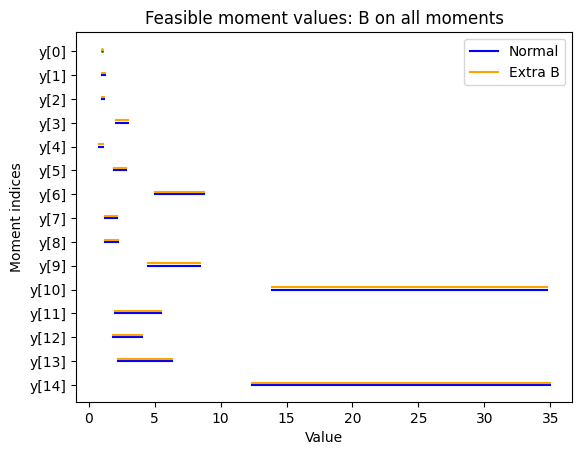

In [348]:
d_bd = 4
d_sd = 4
K = 10

minima, maxima = MOSEK_order(OB_bounds, beta, d_bd, d_sd)
label = "Normal"
for j, (mn, mx) in enumerate(zip(minima, maxima)):
    if mx is None:# or mx > K:
        mx = K
        plt.plot([K, K + 2], [-j, -j], color="blue", linestyle="--")
    if mn == mx: # y[0] = 1
        plt.scatter([mn], [-j], color=colors[i], s=1)
    plt.plot([mn, mx], [-j, -j], color="blue", label=label)
    label = None

minima_B, maxima_B = MOSEK_Btest(OB_bounds, beta, d_bd, d_sd)
label = "Extra B"
for j, (mn, mx) in enumerate(zip(minima_B, maxima_B)):
    if mx is None:# or mx > K:
        mx = K
        plt.plot([K, K + 2], [-j + 0.1, -j + 0.1], color="orange", linestyle="--")
    if mn == mx: # y[0] = 1
        plt.scatter([mn], [-j + 0.1], color="orange", s=1)
    plt.plot([mn, mx], [-j + 0.1, -j + 0.1], color="orange", label=label)
    label = None

plt.legend()
plt.yticks([-i for i in range(len(minima))], [f'y[{i}]' for i in range(len(minima))])
plt.ylabel("Moment indices")
plt.xlabel("Value")
plt.title("Feasible moment values: B on all moments")

In [349]:
for i in range(len(minima)):
    print(minima[i] - minima_B[i], maxima[i] - maxima_B[i])

0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0


# Unknown status

In [77]:
import sys

In [93]:
def MOSEK_unkown(OB_bounds, beta, d_bd, d_sd):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)

    with Model('MOSEK-SDP') as md: 

        # logging
        md.setLogHandler(sys.stdout)

        # variables
        y = md.variable('y', Nd, Domain.greaterThan(0.))

        # variable dict
        variables = {
            'y': y
        }

        # moment matrices
        for s in range(S + 1):

            # restrict to d_sd
            M_s = MOSEK_construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s

            # PSD
            md.constraint(f'M_{s}_PSD', M_s == Domain.inPSDCone())

        # moment bounds

        # get CI bounds on OB moments (up to order d_bd)
        y_lb = OB_bounds[0, :Nbd]
        y_ub = OB_bounds[1, :Nbd]

        # B scaling matrix
        B = compute_B(beta, S, U, d_bd)

        # moment bounds
        md.constraint('y_UB', B @ y[:Nbd] <= y_ub)
        md.constraint('y_LB', B @ y[:Nbd] >= y_lb)

        # fixed moment
        md.constraint('y0', y[0] == 1)

        # optimize
        md.objective(0)
        md.solve()
        problem_status = md.getProblemStatus()
        print(f"Status {problem_status}")
        primal_status = md.getPrimalSolutionStatus()
        print(f"Primal status {primal_status}")
        dual_status = md.getDualSolutionStatus()
        print(f"Dual status {dual_status}")
        obj = md.primalObjValue()
        print(f"Obj {obj}")
        y_feas = y.level()
        
    return y_feas

In [94]:
# read fibroblast transcript counts
data_FIB = pd.read_csv("../../Real-Data-2/Data/GSE151334_FIB_counts_thresh.csv", index_col=0)

# load capture
beta = np.loadtxt("../../Real-Data-2/Capture/beta_FIB.txt")

# load RNA types
biotypes_dict = json.load(open("../../Real-Data-2/Biotypes/biotypes_FIB.json"))

# select indices of protein coding mRNA and non-coding miRNA
pcRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "protein_coding"]
miRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "miRNA"]

# separate data
data_FIB_pcRNA = data_FIB.iloc[pcRNA_indices]
data_FIB_miRNA = data_FIB.iloc[miRNA_indices]

In [95]:
# select
miRNA = "MIR100"
mRNA_idx = 1

# construct sample
sample_miRNA = data_FIB_miRNA.loc[miRNA]
sample_mRNA = data_FIB_pcRNA.iloc[mRNA_idx]
sample = list(zip(sample_miRNA, sample_mRNA))

In [256]:
# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(sample, d_boot, 1000, confidence=0.95)

In [99]:
# orders
d_bd = 3
d_sd = 6

# feasibility
y_feas = MOSEK_unkown(OB_bounds, beta, d_bd, d_sd)

Problem
  Name                   : MOSEK-SDP       
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 21              
  Affine conic cons.     : 3 (97 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 29              
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 5
Eliminator terminated.
Eliminator - tries                  : 1                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes              : 1               
Lin. dep.  - dual attempts          : 0                

SolutionError: Solution status is Undefined but Optimal is expected. Reason: Accessing interior-point solution whose problem status is PrimalInfeasible.

Moving from (3, 5) to (3, 6) the problem becomes "PrimalInfeasible", likely due to numerical issues with the large semidefinite constraint size / large moment values. No issues with lower orders suggests not a major issue.

___

Use `getProblemStatus()` to get feasibility status of problem, `getPrimal/DualSolutionStatus()` are used to get status of existence of Primal/Dual solutions, so in the case of primal infeasibility the primal solution will not exist and so returns 'Undefined'

Previous error returned 'Unkown', this is where the solver finds a point but cannot guarantee it is a solution due to numerical issues, but again suggests that the large model results in numerical issues. However, these are not seen in smaller models used in practice.

## Random objectives

But restrict to order <= 2 moments as only moments in the correlation function

In [223]:
def MOSEK_unkown_opt(OB_bounds, beta, d_bd, d_sd, N=10):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)

    with Model('MOSEK-SDP') as md:

        # logging
        md.setLogHandler(sys.stdout) 

        # variables
        y = md.variable('y', Nd, Domain.greaterThan(0.))

        # variable dict
        variables = {
            'y': y
        }

        # moment matrices
        for s in range(S + 1):

            # restrict to d_sd
            M_s = MOSEK_construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s

            # PSD
            md.constraint(f'M_{s}_PSD', M_s == Domain.inPSDCone())

        # moment bounds

        # get CI bounds on OB moments (up to order d_bd)
        y_lb = OB_bounds[0, :Nbd]
        y_ub = OB_bounds[1, :Nbd]

        # B scaling matrix
        B = compute_B(beta, S, U, d_bd)

        # moment bounds
        md.constraint('y_UB', B @ y[:Nbd] <= y_ub)
        md.constraint('y_LB', B @ y[:Nbd] >= y_lb)

        # fixed moment
        md.constraint('y0', y[0] == 1)

        # optimize
        N2 = compute_Nd(2, 2)
        for i in range(N):
        
            c = np.zeros(Nd)
            c[:N2] = rng.uniform(-1, 1, size=N2)
            trace_expr = 0
            for s in range(S + 1):
                diag_elements = [variables[f'M_{s}'][i, i] for i in range(variables[f'M_{s}'].shape[0])]
                trace_expr += Expr.sum(Expr.vstack(diag_elements))
            md.objective(ObjectiveSense.Minimize, Expr.add(y.T @ c, Expr.mul(1e-7, trace_expr)))# y.T @ c)
            md.solve()
            problem_status = md.getProblemStatus()
            primal_status = md.getPrimalSolutionStatus()
            dual_status = md.getDualSolutionStatus()
            #obj = md.primalObjValue()
            resp = md.getSolverIntInfo("optimizeResponse")
            
            print(resp)
            #print(f"Termination {md.getSolverIntInfo('MSK_RES_TRM_STALL')}")
            print(f"Status {problem_status}")
            print(f"Primal status {primal_status}")
            print(f"Dual status {dual_status}")
            #print(f"Obj {obj}")

In [239]:
# orders
d_bd = 3
d_sd = 5

# feasibility
MOSEK_unkown_opt(OB_bounds, beta, d_bd, d_sd, N=1)

Problem
  Name                   : MOSEK-SDP       
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 21              
  Affine conic cons.     : 3 (63 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 22              
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 5
Eliminator terminated.
Eliminator - tries                  : 1                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes              : 1               
Lin. dep.  - dual attempts          : 0                

Problem status is sometimes `PrimalInfeasible` echoing the issues above where the larger semidefinite constraints lead to numerical errors and no feasible solution.

However, also sometimes `Unkown`: the solver was unable to reach a definitive conclusion about the problem's feasibility or optimality

___

Regularizing objective by adding small constant (e.g. 10^-7) times trace of each semidefinite matrix removes Unkown results and leads to either feasible or infeasible, but infeasible still likely due to numerical errors, and not helpful in obtaining a feasible point.

In [245]:
def MOSEK_random_feas(OB_bounds, beta, d_bd, d_sd, N=10):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)

    with Model('MOSEK-SDP') as md:

        # variables
        y = md.variable('y', Nd, Domain.greaterThan(0.))

        # variable dict
        variables = {
            'y': y
        }

        # moment matrices
        for s in range(S + 1):

            # restrict to d_sd
            M_s = MOSEK_construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s

            # PSD
            md.constraint(f'M_{s}_PSD', M_s == Domain.inPSDCone())

        # moment bounds

        # get CI bounds on OB moments (up to order d_bd)
        y_lb = OB_bounds[0, :Nbd]
        y_ub = OB_bounds[1, :Nbd]

        # B scaling matrix
        B = compute_B(beta, S, U, d_bd)

        # moment bounds
        md.constraint('y_UB', B @ y[:Nbd] <= y_ub)
        md.constraint('y_LB', B @ y[:Nbd] >= y_lb)

        # fixed moment
        md.constraint('y0', y[0] == 1)

        # count feasibility
        feas = 0

        # optimize
        N2 = compute_Nd(2, 2)
        for i in range(N):
        
            try:
                c = np.zeros(Nd)
                c[:N2] = rng.uniform(-1, 1, size=N2)
                md.objective(ObjectiveSense.Minimize, y.T @ c)
                md.solve()
                y_feas = y.level()
                feas += 1
            except SolutionError:
                pass
        
        return feas

In [252]:
# settings
orders = [(2, 2), (2, 3), (2, 4), (2, 5)]
N = 1000

for d_bd, d_sd in orders:

    # feasibility
    feas = MOSEK_random_feas(OB_bounds, beta, d_bd, d_sd, N=N)

    print(f"Order ({d_bd}, {d_sd}) {feas} / {N} feasible")

Order (2, 2) 1000 / 1000 feasible
Order (2, 3) 1000 / 1000 feasible
Order (2, 4) 722 / 1000 feasible
Order (2, 5) 46 / 1000 feasible


In [258]:
d_bd, d_sd = 6, 6
N = 100
feas = MOSEK_random_feas(OB_bounds, beta, d_bd, d_sd, N=N)
print(f"Order ({d_bd}, {d_sd}) {feas} / {N} feasible")

Order (6, 6) 100 / 100 feasible


N Random linear objectives for moments of order <= 2 produces N feasible points for equal orders. As d_sd is increased more runs are not feasible (infeasible or unkown) due to numerical issues.

However, not an issue for equal orders, even when very high.

(Note: no regularization)

# Conclusion

No evidence to suggest increasing d_sd has any effect on existing moments of order <= d_bd, and so on any correlation or infeasibility  (but should be checked in MF ind and BD int cases to verify)

Random linear objectives over moments of order 2 seems to work well to obtain the feasible range of correlation values.

# Updated test

In [387]:
def MOSEK_feasible_points(OB_bounds, beta, d_bd, d_sd, method="single", N=100):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)

    with Model('MOSEK-SDP') as md: 

        # variables
        y = md.variable('y', Nd, Domain.greaterThan(0.))

        # variable dict
        variables = {
            'y': y
        }

        # moment matrices
        for s in range(S + 1):

            # restrict to d_sd
            M_s = MOSEK_construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s

            # PSD
            md.constraint(f'M_{s}_PSD', M_s == Domain.inPSDCone())

        # moment bounds

        # get CI bounds on OB moments (up to order d_bd)
        y_lb = OB_bounds[0, :Nbd]
        y_ub = OB_bounds[1, :Nbd]

        # B scaling matrix
        B = compute_B(beta, S, U, d_bd)

        # moment bounds
        md.constraint('y_UB', B @ y[:Nbd] <= y_ub)
        md.constraint('y_LB', B @ y[:Nbd] >= y_lb)

        # fixed moment
        md.constraint('y0', y[0] == 1)

        # find feasible point(s)
        if method == "single":

            # single feasible point
            md.objective(0)
            md.solve()
            y_feas = [y.level()]

        elif method == "index":

            # feasible point for min and max of each variable (index of y)
            y_feas = []
            for i in range(Nd):
                
                # minimize
                try:
                    md.objective(ObjectiveSense.Minimize, y[i])
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass

                # maximize
                try:
                    md.objective(ObjectiveSense.Maximize, y[i])
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass

        elif method == "random":

            # optimize random linear objectives
            y_feas = []

            for i in range(N):
                try:
                    c = np.zeros(Nd)
                    c[:Nbd] = rng.uniform(-1, 1, size=Nbd)
                    md.objective(ObjectiveSense.Minimize, y.T @ c)
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass
        
        elif method == "random_2":

            # optimize random linear objectives: only including order <2 moments
            y_feas = []

            N2 = compute_Nd(2, 2)
            for i in range(N):
                try:
                    c = np.zeros(Nd)
                    c[:N2] = rng.uniform(-1, 1, size=N2) # only optimize over moments in correlation function
                    md.objective(ObjectiveSense.Minimize, y.T @ c)
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass

    return y_feas

In [359]:
def convex_combinations(y_feas_list, M, R):
    
    # store new points
    y_feas_convex = []
    for m in range(M):

        # sample R feasible points
        ys = rng.choice(y_feas_list, size=R).T

        # sample from R dimensional simplex
        lam = rng.exponential(scale=1, size=R)
        lam = lam / lam.sum()

        # compute convex combination
        y_new = np.sum(lam * ys, axis=1)

        # store
        y_feas_convex.append(y_new)

    return y_feas_convex

In [360]:
def correlations_from_points(d, y_feas_list):

    corr_feas_list = []
    for y_feas in y_feas_list:
        corr_feas_list.append(MOSEK_compute_feasible_correlation(d, y_feas))

    return corr_feas_list

In [361]:
def txt_int(correlation):
    mn = round(min(correlation), 2)
    mx = round(max(correlation), 2)
    return f"({mn}, {mx})"

In [394]:
def plot_corr_hist(axs, correlations, color, name, bins=None, alpha=1):
    axs.hist(correlations, density=True, color=color, label=f"{name} {txt_int(correlations)}", bins=bins, alpha=alpha)
    axs.axvline(min(correlations), color=color, linestyle="--")
    axs.axvline(max(correlations), color=color, linestyle="--")

In [423]:
def plot_data_interval(axs, interval, color="red", name="Data CI"):
    axs.axvspan(interval[0], interval[1], alpha=0.25, color=color, label=f"{name} {txt_int(interval)}")

In [442]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 1
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N)

# data correlation
interval = data_correlation_bootstrap(np.array(sample))

Mean expression 1.09
Correlation statistic -0.24482456326792829 
95% Confidence Interval (-0.2929559108113362, -0.19544333861308222)


### Method comparison: Index, Random, Random (order <= 2)

In [443]:
# settings
d = 3

# index
y_feas_index = MOSEK_feasible_points(OB_bounds, beta, d, d, method="index")
y_corr_index = correlations_from_points(d, y_feas_index)

# random
y_feas_random = MOSEK_feasible_points(OB_bounds, beta, d, d, method="random")
y_corr_random = correlations_from_points(d, y_feas_random)

# random (order <= 2)
y_feas_random_2 = MOSEK_feasible_points(OB_bounds, beta, d, d, method="random_2")
y_corr_random_2 = correlations_from_points(d, y_feas_random_2)

In [446]:
_ = MOSEK_feasible_points(OB_bounds, beta, d, d, method="random", N=10000)

In [447]:
_ = MOSEK_feasible_points(OB_bounds, beta, d, d, method="random_2", N=10000)

Text(0.5, 0.98, 'Feasible Points Optimization Method Comparison')

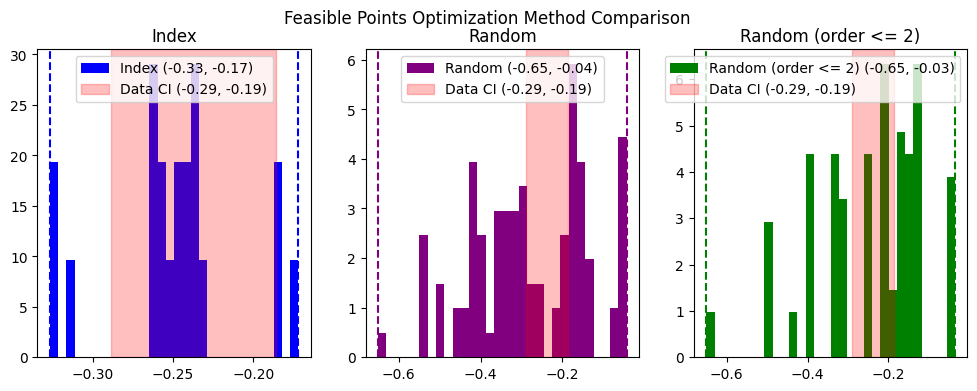

In [408]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), squeeze=False)
plot_corr_hist(axs[0, 0], y_corr_index, "blue", "Index", bins=30)
plot_data_interval(axs[0, 0], interval)
axs[0, 0].set_title("Index")
axs[0, 0].legend()
plot_corr_hist(axs[0, 1], y_corr_random, "purple", "Random", bins=30)
plot_data_interval(axs[0, 1], interval)
axs[0, 1].set_title("Random")
axs[0, 1].legend()
plot_corr_hist(axs[0, 2], y_corr_random_2, "green", "Random (order <= 2)", bins=30)
plot_data_interval(axs[0, 2], interval)
axs[0, 2].set_title("Random (order <= 2)")
axs[0, 2].legend()
fig.suptitle("Feasible Points Optimization Method Comparison")

### Effect of N on random objectives

In [411]:
# settings
d = 3
Ns = [100, 1000, 10000]

corrs = []
for N in Ns:
    y_feas = MOSEK_feasible_points(OB_bounds, beta, d, d, method="random", N=N)
    y_corr = correlations_from_points(d, y_feas)
    corrs.append(y_corr)

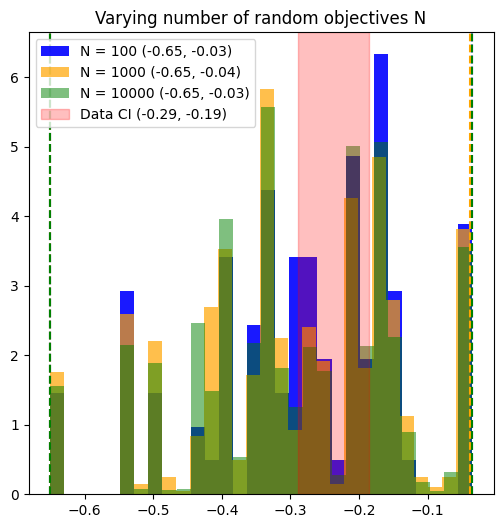

In [412]:
fig, axs = plt.subplots(1, 1, figsize=(6, 6), squeeze=False)
colors = ["blue", "orange", "green"]
alphas = [0.9, 0.7, 0.5]
for i, N in enumerate(Ns):
    plot_corr_hist(axs[0, 0], corrs[i], colors[i], f"N = {N}", bins=30, alpha=alphas[i])
plot_data_interval(axs[0, 0], interval)
axs[0, 0].set_title("Varying number of random objectives N")
axs[0, 0].legend()

### Convex combinations

In [413]:
# settings
d = 3
M = 1000
Rs = [2, 3, 5]

# random
y_feas_random = MOSEK_feasible_points(OB_bounds, beta, d, d, method="random")
y_corr_random = correlations_from_points(d, y_feas_random)

# convex combinations
corrs = []
for R in Rs:
    y_feas_convex = convex_combinations(y_feas_random, M, R)
    y_corr_convex = correlations_from_points(d, y_feas_convex)
    corrs.append(y_corr_convex)

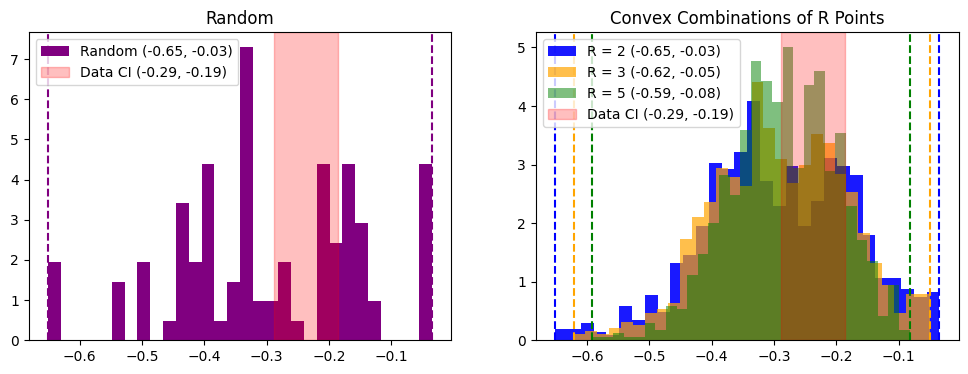

In [415]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), squeeze=False)
plot_corr_hist(axs[0, 0], y_corr_random, "purple", "Random", bins=30)
plot_data_interval(axs[0, 0], interval)
axs[0, 0].set_title("Random")
axs[0, 0].legend()
colors = ["blue", "orange", "green"]
alphas = [0.9, 0.7, 0.5]
for i, R in enumerate(Rs):
    plot_corr_hist(axs[0, 1], corrs[i], colors[i], f"R = {R}", bins=30, alpha=alphas[i])
plot_data_interval(axs[0, 1], interval)
axs[0, 1].set_title("Convex Combinations of R Points")
axs[0, 1].legend()

### Confidence level

In [417]:
# order
d_boot = 6

# bootstrap
OB_bounds_50 = bootstrap(downsample, d_boot, N, confidence=0.5)

# data correlation
interval_50 = data_correlation_bootstrap(np.array(sample), confidence=0.5)

Correlation statistic -0.2402329334017712 
50% Confidence Interval (-0.2569929448077575, -0.2213574425852747)


Text(0.5, 0.98, 'Effect of confidence level')

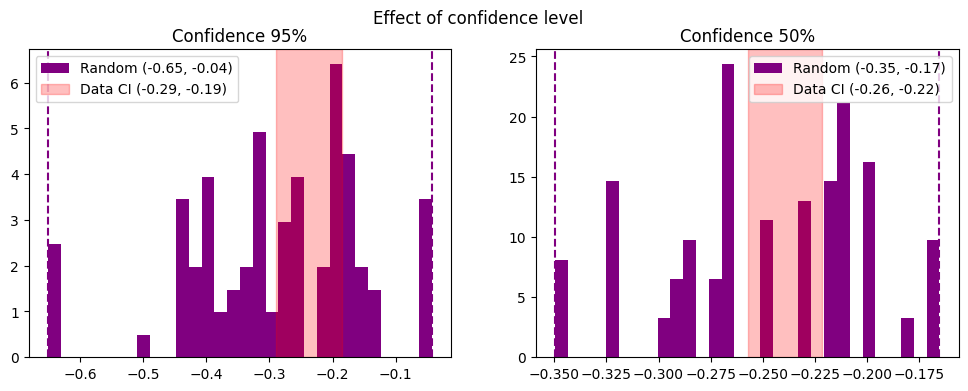

In [422]:
# settings
d = 3

# 95% confidence
y_feas_95 = MOSEK_feasible_points(OB_bounds, beta, d, d, method="random")
y_corr_95 = correlations_from_points(d, y_feas_95)

# 50% confidence
y_feas_50 = MOSEK_feasible_points(OB_bounds_50, beta, d, d, method="random")
y_corr_50 = correlations_from_points(d, y_feas_50)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), squeeze=False)
plot_corr_hist(axs[0, 0], y_corr_95, "purple", "Random", bins=30)
plot_data_interval(axs[0, 0], interval)
axs[0, 0].set_title("Confidence 95%")
axs[0, 0].legend()
plot_corr_hist(axs[0, 1], y_corr_50, "purple", "Random", bins=30)
plot_data_interval(axs[0, 1], interval_50)
axs[0, 1].set_title("Confidence 50%")
axs[0, 1].legend()
fig.suptitle("Effect of confidence level")

### Data simulated with capture efficiency

In [428]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 0.5
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N, confidence=0.5)

# data correlation
interval_OG = data_correlation_bootstrap(np.array(sample), confidence=0.5)
interval_OB = data_correlation_bootstrap(np.array(downsample), confidence=0.5)

Mean expression 0.5715
Correlation statistic -0.28468445096730965 
50% Confidence Interval (-0.30204151509640337, -0.26746293796640114)
Correlation statistic 0.0020033182674206547 
50% Confidence Interval (-0.01952591194379589, 0.023109140232549525)


In [429]:
# settings
d = 3

# random
y_feas_random = MOSEK_feasible_points(OB_bounds, beta, d, d, method="random")
y_corr_random = correlations_from_points(d, y_feas_random)

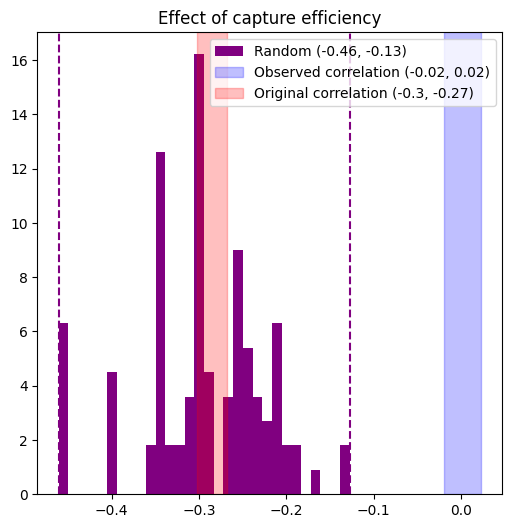

In [430]:
fig, axs = plt.subplots(1, 1, figsize=(6, 6), squeeze=False)
plot_corr_hist(axs[0, 0], y_corr_random, "purple", "Random", bins=30)
plot_data_interval(axs[0, 0], interval_OB, color="blue", name="Observed correlation")
plot_data_interval(axs[0, 0], interval_OG, color="red", name="Original correlation")
axs[0, 0].set_title("Effect of capture efficiency")
axs[0, 0].legend()

### Real data

In [433]:
# read fibroblast transcript counts
data_FIB = pd.read_csv("../../Real-Data-2/Data/GSE151334_FIB_counts_thresh.csv", index_col=0)

# load capture
beta = np.loadtxt("../../Real-Data-2/Capture/beta_FIB.txt")

# load RNA types
biotypes_dict = json.load(open("../../Real-Data-2/Biotypes/biotypes_FIB.json"))

# select indices of protein coding mRNA and non-coding miRNA
pcRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "protein_coding"]
miRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "miRNA"]

# separate data
data_FIB_pcRNA = data_FIB.iloc[pcRNA_indices]
data_FIB_miRNA = data_FIB.iloc[miRNA_indices]

In [438]:
# select
miRNA = "MIR100"
mRNA_idx = 1

# construct sample
sample_miRNA = data_FIB_miRNA.loc[miRNA]
sample_mRNA = data_FIB_pcRNA.iloc[mRNA_idx]
sample = list(zip(sample_miRNA, sample_mRNA))

# order
d_boot = 4

# bootstrap
OB_bounds = bootstrap(sample, d_boot, 1000, confidence=0.95)
OB_bounds_50 = bootstrap(sample, d_boot, 1000, confidence=0.5)

# data correlation
interval = data_correlation_bootstrap(np.array(sample), confidence=0.95)
interval_50 = data_correlation_bootstrap(np.array(sample), confidence=0.5)

Correlation statistic 0.06778759988545108 
95% Confidence Interval (-0.022516405548345175, 0.22644129880004504)
Correlation statistic 0.06778759988545108 
50% Confidence Interval (0.03290123204942612, 0.116835357045067)


Text(0.5, 0.98, 'Real Data')

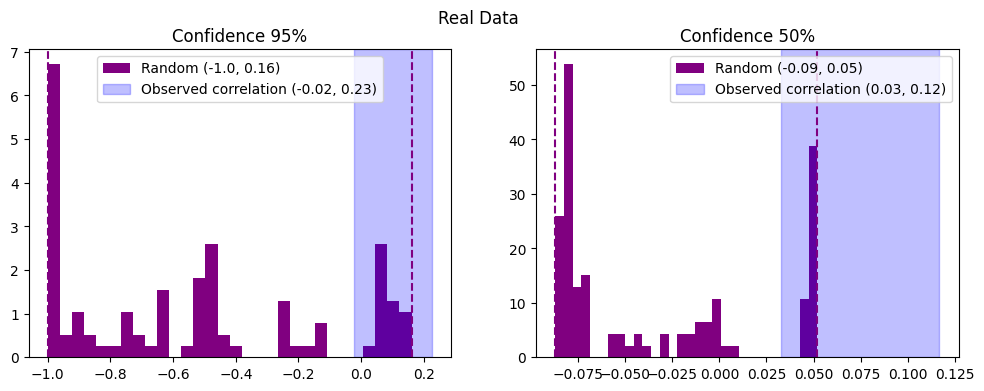

In [441]:
# settings
d = 3

# 95% confidence
y_feas_95 = MOSEK_feasible_points(OB_bounds, beta, d, d, method="random")
y_corr_95 = correlations_from_points(d, y_feas_95)

# 50% confidence
y_feas_50 = MOSEK_feasible_points(OB_bounds_50, beta, d, d, method="random")
y_corr_50 = correlations_from_points(d, y_feas_50)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), squeeze=False)
plot_corr_hist(axs[0, 0], y_corr_95, "purple", "Random", bins=30)
plot_data_interval(axs[0, 0], interval, color="blue", name="Observed correlation")
axs[0, 0].set_title("Confidence 95%")
axs[0, 0].legend()
plot_corr_hist(axs[0, 1], y_corr_50, "purple", "Random", bins=30)
plot_data_interval(axs[0, 1], interval_50, color="blue", name="Observed correlation")
axs[0, 1].set_title("Confidence 50%")
axs[0, 1].legend()
fig.suptitle("Real Data")